#Section 1: Preparing Dataset

##1.1 ChEMBL Data Retrieval for BRD4

In [ ]:


# Step 1: Install the ChEMBL web services client
!pip install chembl_webresource_client tqdm -q

# Step 2: Import required libraries
from chembl_webresource_client.new_client import new_client
import pandas as pd
from tqdm import tqdm

# Step 3: Initialize the ChEMBL API clients
target = new_client.target
activity = new_client.activity
assay = new_client.assay  # Add assay client for confidence scores

# Step 4: Search for BRD4 target (human)
# CHEMBL203 is the canonical identifier for human BRD4
BRD4_target = target.filter(target_chembl_id='CHEMBL1163125').only(['target_chembl_id', 'pref_name', 'organism'])
print(f"Target: {BRD4_target[0]['pref_name']} ({BRD4_target[0]['organism']})")

# Step 5: Retrieve all IC50 activities for BRD4
# We filter for standard_type='IC50' to ensure consistent endpoint
activities = activity.filter(
    target_chembl_id= 'CHEMBL1163125',
    standard_type='IC50',
    standard_units='nM',
    standard_relation='='  # Exact measurements only, no inequalities
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_type',
    'pchembl_value',
    'assay_chembl_id',
    'assay_description',
    'document_chembl_id'
])

# Step 6: Convert to DataFrame for analysis with progress bar
print("Fetching activities from ChEMBL...")
activities_list = [record for record in tqdm(activities, desc="Downloading activities")]
df_raw = pd.DataFrame(activities_list)
print(f"Retrieved {len(df_raw):,} IC50 measurements for BRD4")

# Step 7: Get unique assay IDs and fetch their confidence scores
unique_assay_ids = df_raw['assay_chembl_id'].unique().tolist()
print(f"\nFetching confidence scores for {len(unique_assay_ids):,} unique assays...")

# Query assays in batches to get confidence scores
assay_data = []
batch_size = 50  # ChEMBL API works well with batches of 50

for i in tqdm(range(0, len(unique_assay_ids), batch_size), desc="Downloading assay info"):
    batch_ids = unique_assay_ids[i:i + batch_size]
    batch_assays = assay.filter(assay_chembl_id__in=batch_ids).only([
        'assay_chembl_id',
        'confidence_score',
        'assay_type'
    ])
    assay_data.extend(list(batch_assays))

df_assays = pd.DataFrame(assay_data)
print(f"Retrieved confidence scores for {len(df_assays):,} assays")

# Step 8: Merge activity data with assay confidence scores
df_raw = df_raw.merge(df_assays, on='assay_chembl_id', how='left')

print(f"\nConfidence score distribution:")
print(df_raw['confidence_score'].value_counts().sort_index(ascending=False))

df_raw.to_csv('DATASET_BRD4_chembl_ic50_raw.csv', index=False)
print(f"\nSaved {len(df_raw):,} records to DATASET_BRD4_chembl_ic50_raw.csv")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
Target: Bromodomain-containing protein 4 (Homo sapiens)
Fetching activities from ChEMBL...


Retrieved 11,706 IC50 measurements for BRD4

Fetching confidence scores for 775 unique assays...


Retrieved confidence scores for 775 assays

Confidence score distribution:
confidence_score
9    5579
8    6127
Name: count, dtype: int64

Saved 11,706 records to DATASET_BRD4_chembl_ic50_raw.csv


##1.2 Bioactivity Data Curation

###1.2.1 Endpoint Standardization

In [ ]:
import numpy as np
import pandas as pd
import io

# Check if df_raw exists; if not, prompt for file upload
try:
    df_raw
except NameError:
    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print("Please upload your dataset file (eg DATASET_BRD4_chembl_ic50_raw.csv):")
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import io

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print("Please upload your dataset file (eg DATASET_BRD4_chembl_ic50_raw.csv):")
        display(uploader)

        # Wait for upload
        import time
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        uploaded = {filename: uploader.value[filename]['content']}

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)
    elif filename.endswith(('.xlsx', '.xls')):
        df_raw = pd.read_excel(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)
    elif filename.endswith('.tsv'):
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename, sep='\t')
    else:
        # Default to CSV
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)

    print(f"Loaded '{filename}' with {len(df_raw):,} rows and {len(df_raw.columns)} columns")
    print(f"Columns: {list(df_raw.columns)}")

# Initialize a list to track dropped compounds
dropped_records = []

# Step 1: Remove entries with missing activity values
missing_mask = df_raw['standard_value'].isna() | df_raw['canonical_smiles'].isna()
dropped_missing = df_raw[missing_mask].copy()
dropped_missing['drop_reason'] = 'Missing activity value or SMILES'
dropped_records.append(dropped_missing)

df = df_raw.dropna(subset=['standard_value', 'canonical_smiles']).copy()
print(f"After removing missing values: {len(df):,} entries (dropped {len(dropped_missing):,})")

# Step 2: Convert IC50 (nM) to pIC50
df['pIC50'] = 9 - np.log10(df['standard_value'].astype(float))

# Step 3: Apply reasonable activity range filter
too_low_mask = df['pIC50'] < 3
too_high_mask = df['pIC50'] > 12

dropped_too_low = df[too_low_mask].copy()
dropped_too_low['drop_reason'] = 'pIC50 < 3 (IC50 > 1 mM, essentially inactive)'

dropped_too_high = df[too_high_mask].copy()
dropped_too_high['drop_reason'] = 'pIC50 > 12 (IC50 < 1 pM, unrealistically potent)'

dropped_records.append(dropped_too_low)
dropped_records.append(dropped_too_high)

df = df[(df['pIC50'] >= 3) & (df['pIC50'] <= 12)]
print(f"After activity range filter: {len(df):,} entries (dropped {len(dropped_too_low) + len(dropped_too_high):,})")

# Step 4: Examine the pIC50 distribution
print(f"\npIC50 Statistics:")
print(f"  Mean: {df['pIC50'].mean():.2f}")
print(f"  Std:  {df['pIC50'].std():.2f}")
print(f"  Min:  {df['pIC50'].min():.2f}")
print(f"  Max:  {df['pIC50'].max():.2f}")

# Step 5: Compile and export dropped compounds
dropped_df = pd.concat(dropped_records, ignore_index=True)
dropped_df.to_csv('REPORT_BRD4_ic50_affinity_filter_dropped_compounds.csv', index=False)
print(f"\nDropped compounds report saved to 'REPORT_BRD4_ dropped_compounds.csv'")
print(f"Total compounds dropped: {len(dropped_df):,}")


After removing missing values: 11,699 entries (dropped 7)
After activity range filter: 11,675 entries (dropped 24)

pIC50 Statistics:
  Mean: 6.35
  Std:  1.20
  Min:  3.19
  Max:  10.00

Dropped compounds report saved to 'REPORT_BRD4_ dropped_compounds.csv'
Total compounds dropped: 31


###1.2.2 Duplicate Handling

In [ ]:
# Step 1: Identify duplicate groups
duplicate_groups = df.groupby('canonical_smiles').filter(lambda x: len(x) > 1)
unique_smiles_with_dups = duplicate_groups['canonical_smiles'].nunique()

print(f"Compounds with multiple measurements: {unique_smiles_with_dups:,}")
print(f"Total rows involved in duplicates: {len(duplicate_groups):,}")

# Step 2: Create a report of merged/dropped molecules
duplicate_report = df.groupby('canonical_smiles').agg({
    'molecule_chembl_id': list,  # All ChEMBL IDs that share this SMILES
    'pIC50': list,               # All pIC50 values
    'standard_value': list,      # All IC50 values
}).reset_index()

# Filter to only show compounds that had duplicates
duplicate_report['n_measurements'] = duplicate_report['molecule_chembl_id'].apply(len)
dropped_molecules_report = duplicate_report[duplicate_report['n_measurements'] > 1].copy()

# Add summary stats
dropped_molecules_report['pIC50_range'] = dropped_molecules_report['pIC50'].apply(lambda x: max(x) - min(x))
dropped_molecules_report['kept_chembl_id'] = dropped_molecules_report['molecule_chembl_id'].apply(lambda x: x[0])
dropped_molecules_report['dropped_chembl_ids'] = dropped_molecules_report['molecule_chembl_id'].apply(lambda x: x[1:] if len(x) > 1 else [])

print(f"\nRows dropped due to identical SMILES: {dropped_molecules_report['n_measurements'].sum() - len(dropped_molecules_report):,}")

# Step 3: Save the duplicate report
report_filename = 'REPORT_BRD4_ic50_duplicate_dropped_molecules.csv'
dropped_molecules_report.to_csv(report_filename, index=False)
print(f"\nSaved duplicate report to {report_filename}")

# Step 4: Proceed with aggregation
df['standard_value'] = df['standard_value'].astype(float)
df_aggregated = df.groupby('canonical_smiles').agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'median',
    'standard_value': 'median',
}).reset_index()

print(f"\nUnique compounds after aggregation: {len(df_aggregated):,}")


Compounds with multiple measurements: 2,377
Total rows involved in duplicates: 6,294

Rows dropped due to identical SMILES: 3,917

Saved duplicate report to REPORT_BRD4_ic50_duplicate_dropped_molecules.csv

Unique compounds after aggregation: 7,758


###1.2.3 Activity Cliff Awareness

In [ ]:
!pip install rdkit

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

# Step 1: Calculate Morgan fingerprints for similarity analysis
def get_morgan_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

# Step 2: Generate fingerprints (this may take a moment)
print("Generating fingerprints for activity cliff analysis...")
df_aggregated['fp'] = df_aggregated['canonical_smiles'].apply(get_morgan_fp)
df_valid = df_aggregated.dropna(subset=['fp']).copy()
print(f"Compounds with valid fingerprints: {len(df_valid):,}")

# Step 3: Sample-based activity cliff detection
# Full pairwise comparison is O(n^2); we sample for efficiency
n_samples = min(1000, len(df_valid))
sample_idx = np.random.choice(len(df_valid), n_samples, replace=False)
sample_df = df_valid.iloc[sample_idx]

cliff_pairs = []
fps = list(sample_df['fp'])
pic50s = list(sample_df['pIC50'])

for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        # Calculate Tanimoto similarity
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        # Activity cliff: high similarity (>0.85) but large pIC50 difference (>2)
        if sim > 0.85 and abs(pic50s[i] - pic50s[j]) > 2:
            cliff_pairs.append((i, j, sim, abs(pic50s[i] - pic50s[j])))

print(f"\nActivity cliffs detected (in sample): {len(cliff_pairs)}")
if cliff_pairs:
    print("These represent challenging cases for QSAR prediction.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 19.4 MB/s eta 0:00:00
Generating fingerprints for activity cliff analysis...
Compounds with valid fingerprints: 7,758

Activity cliffs detected (in sample): 1
These represent challenging cases for QSAR prediction.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


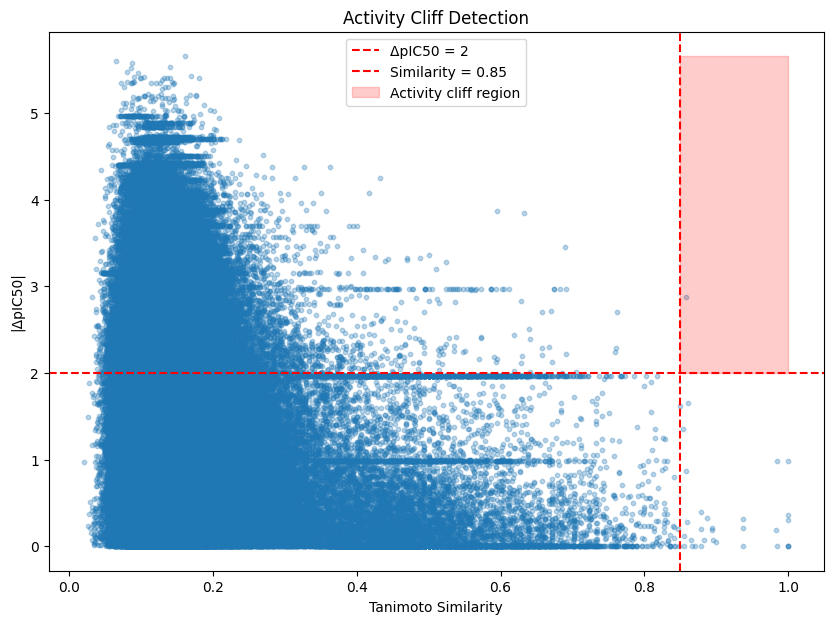

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate all pairwise similarities and activity differences (sampled)
sim_list, delta_pic50_list = [], []

for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        delta = abs(pic50s[i] - pic50s[j])
        sim_list.append(sim)
        delta_pic50_list.append(delta)

plt.figure(figsize=(10, 7))
plt.scatter(sim_list, delta_pic50_list, alpha=0.3, s=10)
plt.axhline(y=2, color='red', linestyle='--', label='ΔpIC50 = 2')
plt.axvline(x=0.85, color='red', linestyle='--', label='Similarity = 0.85')
plt.fill_between([0.85, 1.0], 2, max(delta_pic50_list), alpha=0.2, color='red', label='Activity cliff region')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('|ΔpIC50|')
plt.title('Activity Cliff Detection')
plt.legend()
plt.show()


##1.3 Chemical Structure Curation

###1.3.1 Structure Standardization Pipeline

In [ ]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.SaltRemover import SaltRemover
from tqdm import tqdm

# Careful when using this. This suppresses all warnings from RDKit
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Enable tqdm for pandas
tqdm.pandas()

# Initialize standardization tools
salt_remover = SaltRemover()
uncharger = rdMolStandardize.Uncharger()
normalizer = rdMolStandardize.Normalizer()
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()

def standardize_molecule(smiles):
    """
    Apply publication-grade molecular standardization.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        # Remove salts (keep largest fragment)
        mol = salt_remover.StripMol(mol)

        # Normalize functional groups
        mol = normalizer.normalize(mol)

        # Neutralize charges
        mol = uncharger.uncharge(mol)

        # Canonicalize tautomers
        mol = tautomer_enumerator.Canonicalize(mol)

        # Return canonical SMILES
        return Chem.MolToSmiles(mol, canonical=True)

    except Exception:
        return None

# Apply standardization with progress bar
print("Standardizing molecular structures...")
df_valid['smiles_standardized'] = df_valid['canonical_smiles'].progress_apply(standardize_molecule)

n_before = len(df_valid)
df_curated = df_valid.dropna(subset=['smiles_standardized']).copy()
n_after = len(df_curated)
print(f"Standardization complete: {n_after:,} / {n_before:,} compounds retained")


Standardizing molecular structures...


100%|██████████| 7758/7758 [04:37<00:00, 27.98it/s]

Standardization complete: 7,758 / 7,758 compounds retained


###1.3.2 Duplicate Removal After Standardization

In [ ]:
# Check for duplicates after standardization
n_unique_before = df_curated['smiles_standardized'].nunique()
n_total = len(df_curated)

print(f"Total entries: {n_total:,}")
print(f"Unique standardized SMILES: {n_unique_before:,}")
print(f"New duplicates revealed: {n_total - n_unique_before:,}")

# Aggregate duplicates by taking median pIC50
df_final = df_curated.groupby('smiles_standardized').agg(
    molecule_chembl_id=('molecule_chembl_id', 'first'),
    pIC50=('pIC50', 'median'),
).reset_index()

df_final = df_final.rename(columns={'smiles_standardized': 'smiles'})
print(f"\nFinal curated dataset: {len(df_final):,} unique compounds")


Total entries: 7,758
Unique standardized SMILES: 7,634
New duplicates revealed: 124

Final curated dataset: 7,634 unique compounds


###1.3.3 Stereochemistry Handling

In [ ]:
import requests
from tqdm import tqdm

# Analyze stereochemistry in the dataset
tqdm.pandas(desc="Counting stereocenters")

def count_stereocenters(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))

def has_undefined_stereo(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    return any(c[1] == '?' for c in centers)

# Analyze the dataset
df_final['n_stereocenters'] = df_final['smiles'].progress_apply(count_stereocenters)

tqdm.pandas(desc="Checking undefined stereo")
df_final['undefined_stereo'] = df_final['smiles'].progress_apply(has_undefined_stereo)

n_with_stereo = (df_final['n_stereocenters'] > 0).sum()
n_undefined = df_final['undefined_stereo'].sum()

print(f"Compounds with stereocenters: {n_with_stereo:,}")
print(f"Compounds with undefined stereochemistry: {n_undefined:,}")

# Query ChEMBL for original structures to resolve undefined stereochemistry
def batch_query_chembl(chembl_ids, batch_size=50):
    """Batch query ChEMBL for molfiles with better stereo annotation."""
    results = {}

    for i in tqdm(range(0, len(chembl_ids), batch_size), desc="Querying ChEMBL"):
        batch = chembl_ids[i:i+batch_size]
        ids_str = ";".join(batch)
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/set/{ids_str}.sdf"

        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                suppl = Chem.SDMolSupplier()
                suppl.SetData(response.text)
                for mol in suppl:
                    if mol and mol.HasProp('chembl_id'):
                        cid = mol.GetProp('chembl_id')
                        results[cid] = Chem.MolToSmiles(mol, isomericSmiles=True)
        except Exception as e:
            continue

    return results

if n_undefined > 0:
    print(f"\nQuerying ChEMBL for {n_undefined:,} compounds with undefined stereochemistry...")
    undefined_ids = df_final[df_final['undefined_stereo']]['molecule_chembl_id'].tolist()
    updated_smiles = batch_query_chembl(undefined_ids)

    # Update SMILES where ChEMBL returned a structure
    df_final['smiles'] = df_final.apply(
        lambda row: updated_smiles.get(row['molecule_chembl_id'], row['smiles']), axis=1
    )

    # Re-check undefined stereo after update
    tqdm.pandas(desc="Re-checking undefined stereo")
    df_final['undefined_stereo'] = df_final['smiles'].progress_apply(has_undefined_stereo)

    n_still_undefined = df_final['undefined_stereo'].sum()
    n_resolved = n_undefined - n_still_undefined

    print(f"\nStereochemistry resolved for {n_resolved:,} compounds")
    print(f"Still undefined: {n_still_undefined:,} compounds")
else:
    print("\nNo undefined stereochemistry to resolve.")


Checking undefined stereo: 100%|██████████| 7634/7634 [00:05<00:00, 1306.56it/s]


Compounds with stereocenters: 3,902
Compounds with undefined stereochemistry: 2,356

Querying ChEMBL for 2,356 compounds with undefined stereochemistry...


Re-checking undefined stereo: 100%|██████████| 7634/7634 [00:06<00:00, 1260.24it/s]


Stereochemistry resolved for 0 compounds
Still undefined: 2,356 compounds


###1.3.4 Quality Control Summary

In [ ]:
# Generate quality control summary
print("=" * 60)
print("DATA CURATION SUMMARY")
print("=" * 60)
print(f"Target: BRD4 (CHEMBL203)")
print(f"Endpoint: pIC50 (derived from IC50, nM)")
print(f"")
print(f"Dataset Statistics:")
print(f"  Total compounds: {len(df_final):,}")
print(f"  pIC50 range: {df_final['pIC50'].min():.2f} - {df_final['pIC50'].max():.2f}")
print(f"  pIC50 mean: {df_final['pIC50'].mean():.2f} ± {df_final['pIC50'].std():.2f}")

# Save curated dataset
output_file = 'DATASET_BRD4_ic50_cleaned_compounds.csv'
df_final.to_csv(output_file, index=False)
print(f"\nSaved: {output_file}")

# Download to local computer
from google.colab import files
files.download(output_file)


DATA CURATION SUMMARY
Target: BRD4 (CHEMBL203)
Endpoint: pIC50 (derived from IC50, nM)

Dataset Statistics:
  Total compounds: 7,634
  pIC50 range: 3.19 - 9.52
  pIC50 mean: 6.26 ± 1.18

Saved: DATASET_BRD4_ic50_cleaned_compounds.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 2: Molecular Representations

##2.1 Setup and Data Loading

In [ ]:
!pip install rdkit -q

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import io
from rdkit import Chem
from rdkit import __version__ as rdkit_version

print(f"RDKit version: {rdkit_version}")

# Step 2: Load the curated dataset from Part 1
# Try Google Colab upload first, fall back to ipywidgets
try:
    from google.colab import files
    print("Please upload your dataset file (DATASET_BRD4_ic50_cleaned_compounds):")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    file_content = uploaded[filename]
except ImportError:
    # For Jupyter Notebook
    import ipywidgets as widgets
    from IPython.display import display

    uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
    print("Please upload your dataset file (CSV, Excel, or TSV):")
    display(uploader)

    # Wait for upload
    import time
    while not uploader.value:
        time.sleep(0.1)

    filename = list(uploader.value.keys())[0]
    file_content = uploader.value[filename]['content']

# Read the file based on extension
if filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
elif filename.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.tsv'):
    df = pd.read_csv(io.BytesIO(file_content), sep='\t')
else:
    df = pd.read_csv(io.BytesIO(file_content))

print(f"Loaded '{filename}' with {len(df):,} rows and {len(df.columns)} columns")



RDKit version: 2025.09.4
Please upload your dataset file (DATASET_egfr_ic50_cleaned_compounds):


Saving DATASET_egfr_ic50_cleaned_compounds (1).csv to DATASET_egfr_ic50_cleaned_compounds (1).csv
Loaded 'DATASET_egfr_ic50_cleaned_compounds (1).csv' with 7,634 rows and 5 columns


##2.2 Chemical Fingerprints

###2.2.1 Morgan/ECFP Fingerprints

In [ ]:
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

def generate_morgan_fingerprint(mol, radius=2, n_bits=2048):
    """
    Generate Morgan (ECFP) fingerprint as a bit vector.

    Parameters:
    - radius: 2 gives ECFP4, 3 gives ECFP6
    - n_bits: fingerprint length (2048 is standard)

    Returns numpy array of shape (n_bits,)
    """
    if mol is None:
        return None

    # Use the new MorganGenerator API
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprintAsNumPy(mol)
    return fp

# Create RDKit Mol objects from SMILES
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

# Check for any failures
n_failed = df['mol'].isna().sum()
print(f"Successfully converted: {len(df) - n_failed} | Failed: {n_failed}")

# Drop any rows where conversion failed
if n_failed > 0:
    df = df.dropna(subset=['mol']).reset_index(drop=True)

# Generate ECFP4 fingerprints for all compounds
print("Generating Morgan/ECFP4 fingerprints (radius=2, 2048 bits)...")
ecfp4_fps = df['mol'].progress_apply(lambda m: generate_morgan_fingerprint(m, radius=2, n_bits=2048))

# Convert to DataFrame with meaningful column names
ecfp4_matrix = np.vstack(ecfp4_fps.values)
ecfp4_columns = [f'ECFP4_{i}' for i in range(2048)]
df_ecfp4 = pd.DataFrame(ecfp4_matrix, columns=ecfp4_columns, index=df.index)

print(f"ECFP4 fingerprint matrix shape: {df_ecfp4.shape}")
print(f"Bits set per molecule (mean): {ecfp4_matrix.sum(axis=1).mean():.1f}")


Successfully converted: 7634 | Failed: 0
Generating Morgan/ECFP4 fingerprints (radius=2, 2048 bits)...


100%|██████████| 7634/7634 [00:00<00:00, 8486.89it/s]


ECFP4 fingerprint matrix shape: (7634, 2048)
Bits set per molecule (mean): 57.9


###2.2.2 MACCS Keys

In [ ]:
from rdkit.Chem import MACCSkeys
from tqdm import tqdm

tqdm.pandas()

def generate_maccs_fingerprint(mol):
    """
    Generate MACCS keys fingerprint (166 bits).

    MACCS keys are predefined structural patterns.
    Each bit has a known chemical interpretation.
    """
    if mol is None:
        return None
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

# Generate MACCS fingerprints for all compounds
print("Generating MACCS key fingerprints (166 bits)...")
maccs_fps = df['mol'].progress_apply(generate_maccs_fingerprint)

# Convert to DataFrame
maccs_matrix = np.vstack(maccs_fps.values)
maccs_columns = [f'MACCS_{i}' for i in range(167)]  # MACCS has 167 bits (0-166)
df_maccs = pd.DataFrame(maccs_matrix, columns=maccs_columns, index=df.index)

print(f"MACCS fingerprint matrix shape: {df_maccs.shape}")
print(f"Bits set per molecule (mean): {maccs_matrix.sum(axis=1).mean():.1f}")


Generating MACCS key fingerprints (166 bits)...


100%|██████████| 7634/7634 [00:16<00:00, 454.44it/s]

MACCS fingerprint matrix shape: (7634, 167)
Bits set per molecule (mean): 59.8


###2.2.3 RDKit Topological Fingerprints

In [ ]:
from rdkit.Chem import RDKFingerprint
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

def generate_rdkit_fingerprint(mol, n_bits=2048):
    """
    Generate RDKit topological fingerprint.

    Encodes hashed paths through the molecular graph.
    Complementary to circular fingerprints like ECFP.
    """
    if mol is None:
        return None
    fp = RDKFingerprint(mol, fpSize=n_bits)
    return np.array(fp)

# Generate RDKit fingerprints for all compounds
print("Generating RDKit topological fingerprints (2048 bits)...")
rdkit_fps = df['mol'].progress_apply(lambda m: generate_rdkit_fingerprint(m, n_bits=2048))

# Convert to DataFrame
rdkit_matrix = np.vstack(rdkit_fps.values)
rdkit_columns = [f'RDKit_{i}' for i in range(2048)]
df_rdkit = pd.DataFrame(rdkit_matrix, columns=rdkit_columns, index=df.index)

print(f"RDKit fingerprint matrix shape: {df_rdkit.shape}")
print(f"Bits set per molecule (mean): {rdkit_matrix.sum(axis=1).mean():.1f}")


Generating RDKit topological fingerprints (2048 bits)...


100%|██████████| 7634/7634 [00:41<00:00, 186.02it/s]

RDKit fingerprint matrix shape: (7634, 2048)
Bits set per molecule (mean): 1218.5


##2.3 Molecular Descriptors

###2.3.1 RDKit 2D Descriptor Calculation

In [ ]:
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

# Step 1: Get the list of all available 2D descriptors
descriptor_names = [desc[0] for desc in Descriptors.descList]
print(f"Total RDKit 2D descriptors available: {len(descriptor_names)}")

# Step 2: Create a descriptor calculator
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

# Step 3: Calculate descriptors for all molecules
def calculate_descriptors(mol):
    """Calculate all RDKit 2D descriptors for a molecule."""
    if mol is None:
        return [np.nan] * len(descriptor_names)
    try:
        return list(calculator.CalcDescriptors(mol))
    except Exception:
        return [np.nan] * len(descriptor_names)

print("Calculating molecular descriptors...")
descriptor_values = df['mol'].progress_apply(calculate_descriptors)

# Step 4: Convert to DataFrame
df_descriptors = pd.DataFrame(
    descriptor_values.tolist(),
    columns=descriptor_names,
    index=df.index
)

print(f"Descriptor matrix shape: {df_descriptors.shape}")


Total RDKit 2D descriptors available: 217
Calculating molecular descriptors...


100%|██████████| 7634/7634 [02:56<00:00, 43.20it/s]


Descriptor matrix shape: (7634, 217)


###2.3.2 Descriptor Quality Control

In [ ]:
from tqdm import tqdm

# Step 1: Replace infinite values with NaN
df_descriptors = df_descriptors.replace([np.inf, -np.inf], np.nan)

# Step 2: Count missing values per descriptor
missing_counts = df_descriptors.isna().sum()
high_missing = missing_counts[missing_counts > len(df) * 0.1]  # >10% missing
print(f"Descriptors with >10% missing values: {len(high_missing)}")

# Step 3: Remove descriptors with >10% missing values
valid_descriptors = missing_counts[missing_counts <= len(df) * 0.1].index.tolist()
df_descriptors_clean = df_descriptors[valid_descriptors].copy()
print(f"Descriptors retained: {len(valid_descriptors)}")

# Step 4: Fill remaining missing values with column median
# Median is robust to outliers
for col in tqdm(df_descriptors_clean.columns, desc="Filling missing values"):
    median_val = df_descriptors_clean[col].median()
    df_descriptors_clean[col] = df_descriptors_clean[col].fillna(median_val)

# Step 5: Verify no missing values remain
remaining_nan = df_descriptors_clean.isna().sum().sum()
print(f"Remaining missing values: {remaining_nan}")


Descriptors with >10% missing values: 0
Descriptors retained: 217


Filling missing values: 100%|██████████| 217/217 [00:00<00:00, 3029.20it/s]

Remaining missing values: 0


###2.3.3 Removing Low-Variance Descriptors

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from tqdm import tqdm

# Create progress bar for the steps
steps = ['Calculate variance', 'Count zero-variance', 'Apply threshold filter',
         'Get selected features', 'Create filtered DataFrame']

with tqdm(total=len(steps), desc="Variance Filtering") as pbar:
    # Step 1: Calculate variance for each descriptor
    pbar.set_description("Calculating variance")
    variances = df_descriptors_clean.var()
    print(f"\nVariance range: {variances.min():.6f} to {variances.max():.2f}")
    pbar.update(1)

    # Step 2: Count zero-variance descriptors
    pbar.set_description("Counting zero-variance")
    zero_var = (variances == 0).sum()
    print(f"Zero-variance descriptors: {zero_var}")
    pbar.update(1)

    # Step 3: Apply variance threshold filter
    pbar.set_description("Applying threshold filter")
    selector = VarianceThreshold(threshold=0.01)
    selector.fit(df_descriptors_clean)
    pbar.update(1)

    # Step 4: Get selected feature names
    pbar.set_description("Getting selected features")
    selected_mask = selector.get_support()
    selected_descriptors = df_descriptors_clean.columns[selected_mask].tolist()
    print(f"Descriptors after variance filter: {len(selected_descriptors)}")
    pbar.update(1)

    # Step 5: Create filtered descriptor DataFrame
    pbar.set_description("Creating filtered DataFrame")
    df_descriptors_filtered = df_descriptors_clean[selected_descriptors].copy()
    print(f"Final descriptor matrix shape: {df_descriptors_filtered.shape}")
    pbar.update(1)

    pbar.set_description("Complete")


Complete: 100%|██████████| 5/5 [00:00<00:00, 58.24it/s]


Variance range: 0.000000 to 118302577636816111156891180658107418148864.00
Zero-variance descriptors: 16
Descriptors after variance filter: 173
Final descriptor matrix shape: (7634, 173)


###2.3.4 Removing Highly Correlated Descriptors

In [ ]:
from tqdm import tqdm

def remove_correlated_features(df, threshold=0.95):
    """
    Remove highly correlated features from a DataFrame.

    For each pair with |correlation| > threshold, removes the
    feature with higher mean absolute correlation to all others.

    Parameters:
    - df: DataFrame of features
    - threshold: correlation threshold (default 0.95)

    Returns: list of features to keep
    """
    # Calculate correlation matrix
    corr_matrix = df.corr().abs()

    # Get upper triangle (avoid duplicate pairs)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find features to drop
    to_drop = set()
    for col in tqdm(upper_tri.columns, desc="Checking correlations"):
        # Find features correlated above threshold with this column
        correlated = upper_tri.index[upper_tri[col] > threshold].tolist()
        for corr_feat in correlated:
            # Keep feature with lower mean correlation
            if corr_matrix[col].mean() > corr_matrix[corr_feat].mean():
                to_drop.add(col)
            else:
                to_drop.add(corr_feat)

    return [c for c in df.columns if c not in to_drop]

# Apply correlation filter
print("Removing highly correlated descriptors (threshold=0.95)...")
uncorrelated_descriptors = remove_correlated_features(df_descriptors_filtered, threshold=0.95)
df_descriptors_final = df_descriptors_filtered[uncorrelated_descriptors].copy()

print(f"Descriptors before correlation filter: {len(df_descriptors_filtered.columns)}")
print(f"Descriptors after correlation filter: {len(uncorrelated_descriptors)}")
print(f"Removed {len(df_descriptors_filtered.columns) - len(uncorrelated_descriptors)} correlated features")


Removing highly correlated descriptors (threshold=0.95)...


Checking correlations: 100%|██████████| 173/173 [00:00<00:00, 5212.94it/s]

Descriptors before correlation filter: 173
Descriptors after correlation filter: 143
Removed 30 correlated features


##2.4 Feature Matrix Assembly

###2.4.1 Assembling the Fingerprint Dataset

In [ ]:
# Step 1: Create metadata columns
df_metadata = df[['molecule_chembl_id', 'smiles', 'pIC50']].copy()

# Step 2: Combine all fingerprints
df_fingerprints_combined = pd.concat([
    df_metadata.reset_index(drop=True),
    df_ecfp4.reset_index(drop=True),
    df_maccs.reset_index(drop=True),
    df_rdkit.reset_index(drop=True)
], axis=1)

print(f"Combined fingerprint dataset shape: {df_fingerprints_combined.shape}")
print(f"  - Metadata columns: 3")
print(f"  - ECFP4 bits: {df_ecfp4.shape[1]}")
print(f"  - MACCS bits: {df_maccs.shape[1]}")
print(f"  - RDKit bits: {df_rdkit.shape[1]}")

# Step 3: Also create individual fingerprint files for comparison studies
df_ecfp4_final = pd.concat([df_metadata.reset_index(drop=True), df_ecfp4.reset_index(drop=True)], axis=1)
df_maccs_final = pd.concat([df_metadata.reset_index(drop=True), df_maccs.reset_index(drop=True)], axis=1)
df_rdkit_final = pd.concat([df_metadata.reset_index(drop=True), df_rdkit.reset_index(drop=True)], axis=1)


Combined fingerprint dataset shape: (7634, 4266)
  - Metadata columns: 3
  - ECFP4 bits: 2048
  - MACCS bits: 167
  - RDKit bits: 2048


###2.4.2 Assembling the Descriptor Dataset

In [ ]:
# Assemble descriptor dataset
df_descriptors_dataset = pd.concat([
    df_metadata.reset_index(drop=True),
    df_descriptors_final.reset_index(drop=True)
], axis=1)

print(f"Descriptor dataset shape: {df_descriptors_dataset.shape}")
print(f"  - Metadata columns: 3")
print(f"  - Descriptor features: {df_descriptors_final.shape[1]}")


Descriptor dataset shape: (7634, 146)
  - Metadata columns: 3
  - Descriptor features: 143


###2.4.3 Saving Feature Matrices

In [ ]:
from google.colab import files

# Save all feature matrices
print("Saving feature matrices...")

# Combined fingerprints
df_fingerprints_combined.to_csv('DATASET_BRD4_fingerprints_combined.csv', index=False)
print(f"  Saved: DATASET_BRD4_fingerprints_combined.csv ({df_fingerprints_combined.shape})")

# Individual fingerprint types (for comparative studies)
df_ecfp4_final.to_csv('DATASET_BRD4_fingerprints_ecfp4.csv', index=False)
print(f"  Saved: DATASET_BRD4_fingerprints_ecfp4.csv ({df_ecfp4_final.shape})")

df_maccs_final.to_csv('DATASET_BRD4_fingerprints_maccs.csv', index=False)
print(f"  Saved: DATASET_BRD4_fingerprints_maccs.csv ({df_maccs_final.shape})")

df_rdkit_final.to_csv('DATASET_BRD4_fingerprints_rdkit.csv', index=False)
print(f"  Saved: DATASET_BRD4_fingerprints_rdkit.csv ({df_rdkit_final.shape})")

# Molecular descriptors
df_descriptors_dataset.to_csv('DATASET_BRD4_descriptors.csv', index=False)
print(f"  Saved: DATASET_BRD4_descriptors.csv ({df_descriptors_dataset.shape})")

print("\nAll feature matrices saved successfully.")

# Download all files
print("\nDownloading files...")
files.download('DATASET_BRD4_fingerprints_combined.csv')
files.download('DATASET_BRD4_fingerprints_ecfp4.csv')
files.download('DATASET_BRD4_fingerprints_maccs.csv')
files.download('DATASET_BRD4_fingerprints_rdkit.csv')
files.download('DATASET_BRD4_descriptors.csv')


Saving feature matrices...
  Saved: DATASET_egfr_fingerprints_combined.csv ((7634, 4266))
  Saved: DATASET_egfr_fingerprints_ecfp4.csv ((7634, 2051))
  Saved: DATASET_egfr_fingerprints_maccs.csv ((7634, 170))
  Saved: DATASET_egfr_fingerprints_rdkit.csv ((7634, 2051))
  Saved: DATASET_egfr_descriptors.csv ((7634, 146))

All feature matrices saved successfully.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 3: Dataset Splitting

##3.1 Scaffold-Based Splitting

###3.1.1 Bemis-Murcko Scaffold Extraction

In [ ]:
import numpy as np
import pandas as pd
import io

def upload_and_load_file(var_name, expected_filename=None):
    """
    Prompt user to upload a file and return as DataFrame.

    Parameters:
        var_name: Name of the variable (for display purposes)
        expected_filename: Suggested filename to help user identify the file
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print(prompt_msg)
        display(uploader)

        # Wait for upload
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# Define required datasets with their expected filenames
required_datasets = {
    'df': 'DATASET_BRD4_ic50_cleaned_compounds.csv',
    'df_desc': 'DATASET_BRD4_descriptors.csv',
    'df_fp_ecfp4': 'DATASET_BRD4_fingerprints_ecfp4.csv',
    'df_fp_maccs': 'DATASET_BRD4_fingerprints_maccs.csv',
    'df_fp_rdkit': 'DATASET_BRD4_fingerprints_rdkit.csv',
    'df_fp_combined': 'DATASET_BRD4_fingerprints_combined.csv'
}

# Check each dataframe and prompt for upload if not defined
if 'df' not in dir():
    df = upload_and_load_file('df', required_datasets['df'])

if 'df_desc' not in dir():
    df_desc = upload_and_load_file('df_desc', required_datasets['df_desc'])

if 'df_fp_ecfp4' not in dir():
    df_fp_ecfp4 = upload_and_load_file('df_fp_ecfp4', required_datasets['df_fp_ecfp4'])

if 'df_fp_maccs' not in dir():
    df_fp_maccs = upload_and_load_file('df_fp_maccs', required_datasets['df_fp_maccs'])

if 'df_fp_rdkit' not in dir():
    df_fp_rdkit = upload_and_load_file('df_fp_rdkit', required_datasets['df_fp_rdkit'])

if 'df_fp_combined' not in dir():
    df_fp_combined = upload_and_load_file('df_fp_combined', required_datasets['df_fp_combined'])

# Summary of loaded datasets
print("=" * 60)
print("Dataset Summary:")
print("=" * 60)
print(f"  df (cleaned compounds): {len(df):,} rows × {len(df.columns)} columns")
print(f"  df_desc:                {len(df_desc):,} rows × {len(df_desc.columns)} columns")
print(f"  df_fp_ecfp4:            {len(df_fp_ecfp4):,} rows × {len(df_fp_ecfp4.columns)} columns")
print(f"  df_fp_maccs:            {len(df_fp_maccs):,} rows × {len(df_fp_maccs.columns)} columns")
print(f"  df_fp_rdkit:            {len(df_fp_rdkit):,} rows × {len(df_fp_rdkit.columns)} columns")
print(f"  df_fp_combined:         {len(df_fp_combined):,} rows × {len(df_fp_combined.columns)} columns")
print("=" * 60)


Please upload the file for 'df_desc' (expected: DATASET_egfr_descriptors.csv):


Saving DATASET_egfr_descriptors.csv to DATASET_egfr_descriptors (1).csv
  ✓ Loaded 'DATASET_egfr_descriptors (1).csv' with 7,634 rows and 146 columns

Please upload the file for 'df_fp_ecfp4' (expected: DATASET_egfr_fingerprints_ecfp4.csv):


Saving DATASET_egfr_fingerprints_ecfp4.csv to DATASET_egfr_fingerprints_ecfp4 (1).csv
  ✓ Loaded 'DATASET_egfr_fingerprints_ecfp4 (1).csv' with 7,634 rows and 2051 columns

Please upload the file for 'df_fp_maccs' (expected: DATASET_egfr_fingerprints_maccs.csv):


Saving DATASET_egfr_fingerprints_maccs.csv to DATASET_egfr_fingerprints_maccs (1).csv
  ✓ Loaded 'DATASET_egfr_fingerprints_maccs (1).csv' with 7,634 rows and 170 columns

Please upload the file for 'df_fp_rdkit' (expected: DATASET_egfr_fingerprints_rdkit.csv):


Saving DATASET_egfr_fingerprints_rdkit.csv to DATASET_egfr_fingerprints_rdkit (1).csv
  ✓ Loaded 'DATASET_egfr_fingerprints_rdkit (1).csv' with 7,634 rows and 2051 columns

Please upload the file for 'df_fp_combined' (expected: DATASET_egfr_fingerprints_combined.csv):


Saving DATASET_egfr_fingerprints_combined.csv to DATASET_egfr_fingerprints_combined (1).csv
  ✓ Loaded 'DATASET_egfr_fingerprints_combined (1).csv' with 7,634 rows and 4266 columns

Dataset Summary:
  df (cleaned compounds): 7,634 rows × 6 columns
  df_desc:                7,634 rows × 146 columns
  df_fp_ecfp4:            7,634 rows × 2051 columns
  df_fp_maccs:            7,634 rows × 170 columns
  df_fp_rdkit:            7,634 rows × 2051 columns
  df_fp_combined:         7,634 rows × 4266 columns


In [ ]:
!pip install rdkit -q
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Generate Murcko scaffolds for each molecule
def get_murcko_scaffold(smiles):
    """Extract Murcko scaffold from SMILES string."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

# Apply scaffold generation
print("Generating Murcko scaffolds...")
df['scaffold'] = df['smiles'].apply(get_murcko_scaffold)

# Filter out compounds where scaffold generation failed
df_valid = df[df['scaffold'].notna()].copy()

print(f"Compounds with valid scaffolds: {len(df_valid):,} / {len(df):,}")
print(f"Failed scaffold generation: {len(df) - len(df_valid):,}")


Generating Murcko scaffolds...
Compounds with valid scaffolds: 7,634 / 7,634
Failed scaffold generation: 0


In [ ]:
from collections import Counter

# Count compounds per scaffold
scaffold_counts = Counter(df_valid['scaffold'])

print(f"Total unique scaffolds: {len(scaffold_counts):,}")
print(f"\nScaffold distribution:")
print(f"  Singletons (1 compound): {sum(1 for c in scaffold_counts.values() if c == 1):,}")
print(f"  Small series (2-5): {sum(1 for c in scaffold_counts.values() if 2 <= c <= 5):,}")
print(f"  Medium series (6-20): {sum(1 for c in scaffold_counts.values() if 6 <= c <= 20):,}")
print(f"  Large series (>20): {sum(1 for c in scaffold_counts.values() if c > 20):,}")

# Show top 10 most common scaffolds
print(f"\nTop 10 scaffolds by compound count:")
for scaffold, count in scaffold_counts.most_common(10):
    print(f"  {count:4d} compounds: {scaffold[:50]}..." if len(scaffold) > 50 else f"  {count:4d} compounds: {scaffold}")


Total unique scaffolds: 3,295

Scaffold distribution:
  Singletons (1 compound): 2,312
  Small series (2-5): 745
  Medium series (6-20): 210
  Large series (>20): 28

Top 10 scaffolds by compound count:
   258 compounds: c1ccc2c(c1)ncc1nncn12
    89 compounds: c1ccc(Cc2nc3c4c(ccc3n2C2CCCCC2)NCCC4)cc1
    84 compounds: c1ccc(Nc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1
    54 compounds: c1ccc(C2=NCc3nncn3-c3sccc32)cc1
    50 compounds: O=C(NCCCCNc1nc2ccccc2n2cnnc12)c1ccccc1
    48 compounds: c1ccc(Nc2nc3c4c(ccc3n2C2CCCCC2)NCCC4)cc1
    47 compounds: c1ccc(CCc2nc3c4c(ccc3n2C2CCCCC2)NCCC4)cc1
    46 compounds: O=c1[nH]cc(-c2ccccc2)c2ccccc12
    40 compounds: O=c1ccc(-c2ccccc2)c[nH]1
    39 compounds: O=C1CCNc2c(cccc2-c2ccccc2)N1


###3.2.2 Implementing Scaffold Split

In [ ]:
def scaffold_split(df, smiles_col='smiles', test_size=0.1, val_size=0.1, random_state=42):
    """
    Perform scaffold-based train/validation/test split.

    All molecules sharing a scaffold are assigned to the same partition.
    Scaffolds are sorted by size (largest first) for balanced splits.

    Returns: train_idx, val_idx, test_idx (lists of DataFrame indices)
    """
    np.random.seed(random_state)

    # Extract scaffolds
    scaffolds = df[smiles_col].apply(get_murcko_scaffold)

    # Group indices by scaffold
    scaffold_to_indices = {}
    for idx, scaffold in zip(df.index, scaffolds):
        if scaffold is None:
            scaffold = f'NONE_{idx}'  # Treat parsing failures as singletons
        if scaffold not in scaffold_to_indices:
            scaffold_to_indices[scaffold] = []
        scaffold_to_indices[scaffold].append(idx)

    # Sort scaffolds by size (largest first) for better balance
    scaffold_sets = list(scaffold_to_indices.values())
    scaffold_sets.sort(key=len, reverse=True)

    # Calculate target sizes
    n_total = len(df)
    n_test = int(n_total * test_size)
    n_val = int(n_total * val_size)

    # Assign scaffolds to splits
    train_idx, val_idx, test_idx = [], [], []

    for indices in scaffold_sets:
        # Assign to smallest partition that hasn't reached target
        if len(test_idx) < n_test:
            test_idx.extend(indices)
        elif len(val_idx) < n_val:
            val_idx.extend(indices)
        else:
            train_idx.extend(indices)

    return train_idx, val_idx, test_idx


In [ ]:
# Perform scaffold-based split
train_idx, val_idx, test_idx = scaffold_split(
    df_valid,
    smiles_col='smiles',
    test_size=0.1,
    val_size=0.1,
    random_state=42
)

# Create split DataFrames
df_train = df_valid.loc[train_idx].copy()
df_val = df_valid.loc[val_idx].copy()
df_test = df_valid.loc[test_idx].copy()

print(f"Scaffold-based split:")
print(f"  Train: {len(df_train):,} compounds ({100*len(df_train)/len(df_valid):.1f}%)")
print(f"  Val:   {len(df_val):,} compounds ({100*len(df_val)/len(df_valid):.1f}%)")
print(f"  Test:  {len(df_test):,} compounds ({100*len(df_test)/len(df_valid):.1f}%)")


Scaffold-based split:
  Train: 6,077 compounds (79.6%)
  Val:   767 compounds (10.0%)
  Test:  790 compounds (10.3%)


###3.1.3 Verifying Split Integrity

In [ ]:
# Verify zero scaffold overlap
train_scaffolds = set(df_train['scaffold'])
val_scaffolds = set(df_val['scaffold'])
test_scaffolds = set(df_test['scaffold'])

train_val_overlap = train_scaffolds.intersection(val_scaffolds)
train_test_overlap = train_scaffolds.intersection(test_scaffolds)
val_test_overlap = val_scaffolds.intersection(test_scaffolds)

print("Scaffold Overlap Verification:")
print(f"  Train-Val overlap: {len(train_val_overlap)} scaffolds")
print(f"  Train-Test overlap: {len(train_test_overlap)} scaffolds")
print(f"  Val-Test overlap: {len(val_test_overlap)} scaffolds")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\n[SUCCESS] Zero scaffold overlap - split integrity verified!")
else:
    print("\n[ERROR] Scaffold overlap detected - check implementation!")


Scaffold Overlap Verification:
  Train-Val overlap: 0 scaffolds
  Train-Test overlap: 0 scaffolds
  Val-Test overlap: 0 scaffolds

[SUCCESS] Zero scaffold overlap - split integrity verified!


##3.2 Activity Distribution Analysis

In [ ]:
# Analyze pIC50 distributions across splits
print("pIC50 Distribution Analysis:")
print(f"{'Partition':<10} {'Count':>8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 58)

for name, data in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f"{name:<10} {len(data):>8,} {data['pIC50'].mean():>8.2f} {data['pIC50'].std():>8.2f} {data['pIC50'].min():>8.2f} {data['pIC50'].max():>8.2f}")

print("-" * 58)
print(f"{'Total':<10} {len(df_valid):>8,} {df_valid['pIC50'].mean():>8.2f} {df_valid['pIC50'].std():>8.2f} {df_valid['pIC50'].min():>8.2f} {df_valid['pIC50'].max():>8.2f}")


pIC50 Distribution Analysis:
Partition     Count     Mean      Std      Min      Max
----------------------------------------------------------
Train         6,077     6.23     1.18     3.19     9.52
Val             767     6.26     1.00     4.00     9.37
Test            790     6.41     1.29     4.09     9.40
----------------------------------------------------------
Total         7,634     6.26     1.18     3.19     9.52


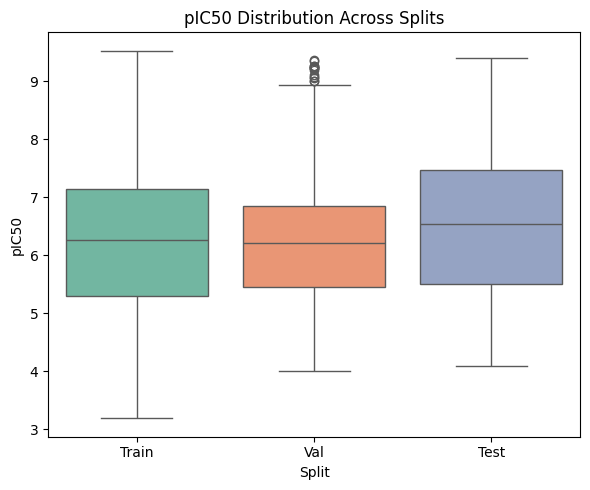

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine data with labels
df_train['Split'] = 'Train'
df_val['Split'] = 'Val'
df_test['Split'] = 'Test'
df_combined = pd.concat([df_train, df_val, df_test])

# Box plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_combined, x='Split', y='pIC50', hue='Split',
            order=['Train', 'Val', 'Test'], palette='Set2', legend=False)
plt.title('pIC50 Distribution Across Splits')
plt.tight_layout()
plt.show()


##3.3 Creating Split Feature Matrices

###3.3.1 Splitting Fingerprint Matrices

In [ ]:
# Create index mapping from SMILES to row position
# This handles potential ordering differences between files
smiles_to_split = {}
for idx in train_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'train'
for idx in val_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'val'
for idx in test_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'test'

def split_by_smiles(df, smiles_col='smiles'):
    """Split DataFrame using SMILES-based assignment."""
    df['split'] = df[smiles_col].map(smiles_to_split)
    train = df[df['split'] == 'train'].drop(columns=['split'])
    val = df[df['split'] == 'val'].drop(columns=['split'])
    test = df[df['split'] == 'test'].drop(columns=['split'])
    return train, val, test

# Split all fingerprint datasets
fp_ecfp4_train, fp_ecfp4_val, fp_ecfp4_test = split_by_smiles(df_fp_ecfp4)
fp_maccs_train, fp_maccs_val, fp_maccs_test = split_by_smiles(df_fp_maccs)
fp_rdkit_train, fp_rdkit_val, fp_rdkit_test = split_by_smiles(df_fp_rdkit)
fp_combined_train, fp_combined_val, fp_combined_test = split_by_smiles(df_fp_combined)

print(f"\nECFP4 split: train={len(fp_ecfp4_train)}, val={len(fp_ecfp4_val)}, test={len(fp_ecfp4_test)}")
print(f"MACCS split: train={len(fp_maccs_train)}, val={len(fp_maccs_val)}, test={len(fp_maccs_test)}")



ECFP4 split: train=6077, val=767, test=790
MACCS split: train=6077, val=767, test=790


###3.3.2 Splitting Descriptor Matrix

In [ ]:
# Split descriptor dataset

desc_train, desc_val, desc_test = split_by_smiles(df_desc)
print(f"Descriptor split: train={len(desc_train)}, val={len(desc_val)}, test={len(desc_test)}")


Descriptor split: train=6077, val=767, test=790


###3.3.3 Saving Split Datasets

In [ ]:
import os
import shutil

# Create splits directory
os.makedirs('splits', exist_ok=True)

# Save ECFP4 splits
fp_ecfp4_train.to_csv('splits/DATASET_ecfp4_train.csv', index=False)
fp_ecfp4_val.to_csv('splits/DATASET_ecfp4_val.csv', index=False)
fp_ecfp4_test.to_csv('splits/DATASET_ecfp4_test.csv', index=False)

# Save MACCS splits
fp_maccs_train.to_csv('splits/DATASET_maccs_train.csv', index=False)
fp_maccs_val.to_csv('splits/DATASET_maccs_val.csv', index=False)
fp_maccs_test.to_csv('splits/DATASET_maccs_test.csv', index=False)

# Save RDKit fingerprint splits
fp_rdkit_train.to_csv('splits/DATASET_rdkit_fp_train.csv', index=False)
fp_rdkit_val.to_csv('splits/DATASET_rdkit_fp_val.csv', index=False)
fp_rdkit_test.to_csv('splits/DATASET_rdkit_fp_test.csv', index=False)

# Save combined fingerprint splits
fp_combined_train.to_csv('splits/DATASET_fingerprints_combined_train.csv', index=False)
fp_combined_val.to_csv('splits/DATASET_fingerprints_combined_val.csv', index=False)
fp_combined_test.to_csv('splits/DATASET_fingerprints_combined_test.csv', index=False)

# Save descriptor splits
desc_train.to_csv('splits/DATASET_descriptors_train.csv', index=False)
desc_val.to_csv('splits/DATASET_descriptors_val.csv', index=False)
desc_test.to_csv('splits/DATASET_descriptors_test.csv', index=False)

print("All split datasets saved to 'splits/' directory")
print(f"Files created: {len(os.listdir('splits'))}")

# Create zip file for download
shutil.make_archive('splits', 'zip', '.', 'splits')
print("\nCreated 'splits.zip' for download")

# If using Google Colab, uncomment below to trigger download:
from google.colab import files
files.download('splits.zip')


All split datasets saved to 'splits/' directory
Files created: 15

Created 'splits.zip' for download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###3.3.4 Visualizing Chemical Space Coverage in Train, Test and Split Subsets


ECFP4:
  Feature columns: 2048
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 6077, Val: 767, Test: 790

MACCS:
  Feature columns: 167
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 6077, Val: 767, Test: 790

RDKit Fingerprints:
  Feature columns: 2048
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 6077, Val: 767, Test: 790

Combined Fingerprints:
  Feature columns: 4263
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 6077, Val: 767, Test: 790

Descriptors:
  Feature columns: 143
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 6077, Val: 767, Test: 790


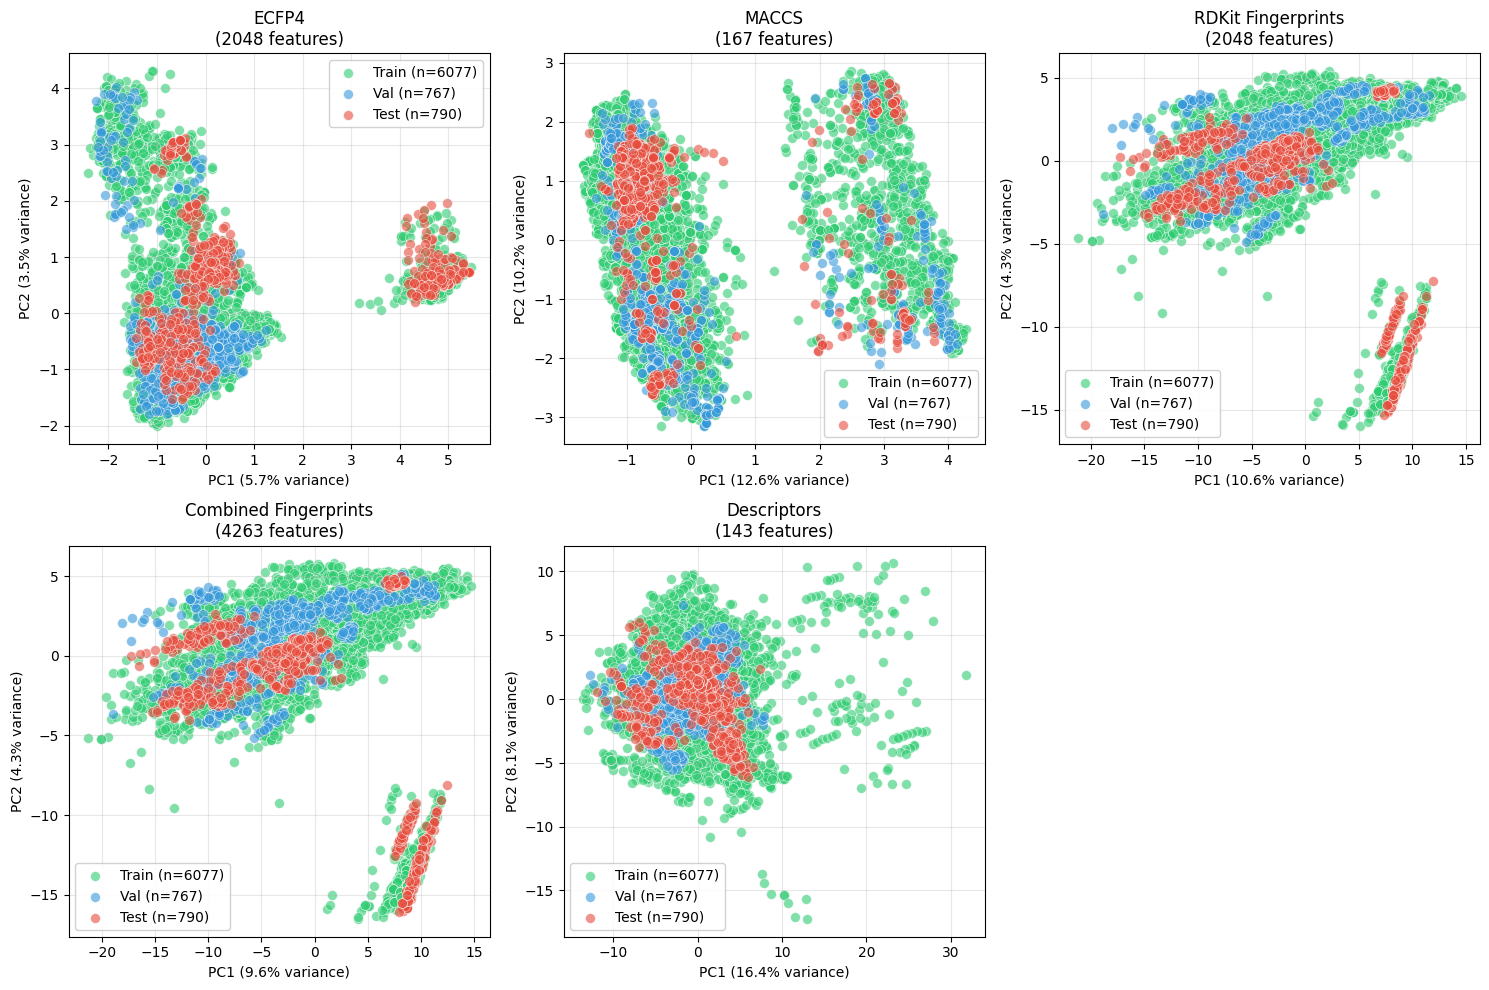

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Define the 5 methods and their file prefixes
methods = {
    'ECFP4': 'DATASET_ecfp4',
    'MACCS': 'DATASET_maccs',
    'RDKit Fingerprints': 'DATASET_rdkit_fp',
    'Combined Fingerprints': 'DATASET_fingerprints_combined',
    'Descriptors': 'DATASET_descriptors'
}

# Columns to exclude (non-feature columns)
EXCLUDE_COLS = ['molecule_chembl_id', 'smiles', 'pIC50']

def detect_feature_columns(df):
    """
    Detect feature columns by excluding specified non-feature columns.
    """
    non_feature_cols = [col for col in df.columns if col in EXCLUDE_COLS]
    feature_cols = [col for col in df.columns if col not in EXCLUDE_COLS]
    return feature_cols, non_feature_cols

def load_splits(file_prefix, splits_dir='splits'):
    """
    Load train, validation, and test splits for a given method.
    """
    train_df = pd.read_csv(f'{splits_dir}/{file_prefix}_train.csv')
    val_df = pd.read_csv(f'{splits_dir}/{file_prefix}_val.csv')
    test_df = pd.read_csv(f'{splits_dir}/{file_prefix}_test.csv')
    return train_df, val_df, test_df

def plot_pca_for_method(method_name, file_prefix, splits_dir='splits', ax=None):
    """
    Perform PCA and plot for train/val/test subsets of a given method.
    """
    # Load data
    train_df, val_df, test_df = load_splits(file_prefix, splits_dir)

    # Detect feature columns
    feature_cols, non_feature_cols = detect_feature_columns(train_df)

    print(f"\n{method_name}:")
    print(f"  Feature columns: {len(feature_cols)}")
    print(f"  Excluded columns: {non_feature_cols}")
    print(f"  Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    # Extract features
    X_train = train_df[feature_cols].values.astype(float)
    X_val = val_df[feature_cols].values.astype(float)
    X_test = test_df[feature_cols].values.astype(float)

    # Only scale for Descriptors
    if method_name == 'Descriptors':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    # Perform PCA (fit on train, transform all)
    pca = PCA(n_components=2)
    train_pca = pca.fit_transform(X_train)
    val_pca = pca.transform(X_val)
    test_pca = pca.transform(X_test)

    # Get explained variance
    var_explained = pca.explained_variance_ratio_ * 100

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(train_pca[:, 0], train_pca[:, 1], alpha=0.6, label=f'Train (n={len(train_df)})',
               c='#2ecc71', edgecolors='white', linewidth=0.5, s=50)
    ax.scatter(val_pca[:, 0], val_pca[:, 1], alpha=0.6, label=f'Val (n={len(val_df)})',
               c='#3498db', edgecolors='white', linewidth=0.5, s=50)
    ax.scatter(test_pca[:, 0], test_pca[:, 1], alpha=0.6, label=f'Test (n={len(test_df)})',
               c='#e74c3c', edgecolors='white', linewidth=0.5, s=50)

    ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
    ax.set_title(f'{method_name}\n({len(feature_cols)} features)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

    return pca, var_explained

# Main execution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (method_name, file_prefix) in enumerate(methods.items()):
    plot_pca_for_method(method_name, file_prefix, splits_dir='splits', ax=axes[idx])

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


#Part 4: Model Development

##4.1 Setup and Data Preparation

In [8]:
import numpy as np
import pandas as pd
import io

def upload_and_load_file(var_name, expected_filename=None):
    """
    Prompt user to upload a file and return as DataFrame.
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print(prompt_msg)
        display(uploader)

        # Wait for upload
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# Define required datasets with their expected filenames
required_datasets = {
    'train_fp': 'DATASET_ecfp4_train.csv',
    'val_fp': 'DATASET_ecfp4_val.csv',
    'test_fp': 'DATASET_ecfp4_test.csv',
    'train_desc': 'DATASET_descriptors_train.csv',
    'val_desc': 'DATASET_descriptors_val.csv',
    'test_desc': 'DATASET_descriptors_test.csv'
}

# Check each dataframe and prompt for upload if not defined
if 'train_fp' not in dir():
    train_fp = upload_and_load_file('train_fp', required_datasets['train_fp'])

if 'val_fp' not in dir():
    val_fp = upload_and_load_file('val_fp', required_datasets['val_fp'])

if 'test_fp' not in dir():
    test_fp = upload_and_load_file('test_fp', required_datasets['test_fp'])

if 'train_desc' not in dir():
    train_desc = upload_and_load_file('train_desc', required_datasets['train_desc'])

if 'val_desc' not in dir():
    val_desc = upload_and_load_file('val_desc', required_datasets['val_desc'])

if 'test_desc' not in dir():
    test_desc = upload_and_load_file('test_desc', required_datasets['test_desc'])

# Summary of loaded datasets
print("=" * 60)
print("Dataset Summary:")
print("=" * 60)
print(f"  ECFP4 Fingerprints:")
print(f"    train_fp:   {train_fp.shape[0]:,} rows × {train_fp.shape[1]} columns")
print(f"    val_fp:     {val_fp.shape[0]:,} rows × {val_fp.shape[1]} columns")
print(f"    test_fp:    {test_fp.shape[0]:,} rows × {test_fp.shape[1]} columns")
print(f"  Molecular Descriptors:")
print(f"    train_desc: {train_desc.shape[0]:,} rows × {train_desc.shape[1]} columns")
print(f"    val_desc:   {val_desc.shape[0]:,} rows × {val_desc.shape[1]} columns")
print(f"    test_desc:  {test_desc.shape[0]:,} rows × {test_desc.shape[1]} columns")
print("=" * 60)


Please upload the file for 'train_fp' (expected: DATASET_ecfp4_train.csv):


Saving DATASET_ecfp4_train.csv to DATASET_ecfp4_train.csv
  ✓ Loaded 'DATASET_ecfp4_train.csv' with 6,077 rows and 2051 columns

Please upload the file for 'val_fp' (expected: DATASET_ecfp4_val.csv):


Saving DATASET_ecfp4_val.csv to DATASET_ecfp4_val.csv
  ✓ Loaded 'DATASET_ecfp4_val.csv' with 767 rows and 2051 columns

Please upload the file for 'test_fp' (expected: DATASET_ecfp4_test.csv):


Saving DATASET_ecfp4_test.csv to DATASET_ecfp4_test.csv
  ✓ Loaded 'DATASET_ecfp4_test.csv' with 790 rows and 2051 columns

Please upload the file for 'train_desc' (expected: DATASET_descriptors_train.csv):


Saving DATASET_descriptors_train.csv to DATASET_descriptors_train.csv
  ✓ Loaded 'DATASET_descriptors_train.csv' with 6,077 rows and 146 columns

Please upload the file for 'val_desc' (expected: DATASET_descriptors_val.csv):


Saving DATASET_descriptors_val.csv to DATASET_descriptors_val.csv
  ✓ Loaded 'DATASET_descriptors_val.csv' with 767 rows and 146 columns

Please upload the file for 'test_desc' (expected: DATASET_descriptors_test.csv):


Saving DATASET_descriptors_test.csv to DATASET_descriptors_test.csv
  ✓ Loaded 'DATASET_descriptors_test.csv' with 790 rows and 146 columns

Dataset Summary:
  ECFP4 Fingerprints:
    train_fp:   6,077 rows × 2051 columns
    val_fp:     767 rows × 2051 columns
    test_fp:    790 rows × 2051 columns
  Molecular Descriptors:
    train_desc: 6,077 rows × 146 columns
    val_desc:   767 rows × 146 columns
    test_desc:  790 rows × 146 columns


###4.1.1 Loading Split Datasets

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f"ECFP4 Fingerprints loaded:")
print(f"  Train: {train_fp.shape}")
print(f"  Val:   {val_fp.shape}")
print(f"  Test:  {test_fp.shape}")


ECFP4 Fingerprints loaded:
  Train: (6077, 2051)
  Val:   (767, 2051)
  Test:  (790, 2051)


###4.1.2 Preparing Feature Matrices

In [10]:
# Identify metadata and feature columns
metadata_cols = ['molecule_chembl_id', 'smiles', 'pIC50']
feature_cols = [c for c in train_fp.columns if c not in metadata_cols]

print(f"Metadata columns: {len(metadata_cols)}")
print(f"Feature columns: {len(feature_cols)}")

# Extract features and targets for fingerprints
X_train_fp = train_fp[feature_cols].values
X_val_fp = val_fp[feature_cols].values
X_test_fp = test_fp[feature_cols].values

y_train = train_fp['pIC50'].values
y_val = val_fp['pIC50'].values
y_test = test_fp['pIC50'].values

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train_fp.shape}")
print(f"  X_val:   {X_val_fp.shape}")
print(f"  X_test:  {X_test_fp.shape}")


Metadata columns: 3
Feature columns: 2048

Feature matrix shapes:
  X_train: (6077, 2048)
  X_val:   (767, 2048)
  X_test:  (790, 2048)


###4.1.3 Preparing Descriptor Features

In [11]:
# Get descriptor feature columns
desc_feature_cols = [c for c in train_desc.columns if c not in metadata_cols]
print(f"Descriptor features: {len(desc_feature_cols)}")

# Extract raw features
X_train_desc_raw = train_desc[desc_feature_cols].values
X_val_desc_raw = val_desc[desc_feature_cols].values
X_test_desc_raw = test_desc[desc_feature_cols].values

# Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_desc = scaler.fit_transform(X_train_desc_raw)
X_val_desc = scaler.transform(X_val_desc_raw)  # Transform only, no fit!
X_test_desc = scaler.transform(X_test_desc_raw)  # Transform only, no fit!

print(f"\nDescriptor scaling complete (fit on train only)")
print(f"  Train mean (should be ~0): {X_train_desc.mean():.4f}")
print(f"  Train std (should be ~1): {X_train_desc.std():.4f}")


Descriptor features: 143

Descriptor scaling complete (fit on train only)
  Train mean (should be ~0): 0.0000
  Train std (should be ~1): 1.0000


###4.1.4 Combining Train and Validation for GridSearchCV

In [12]:
# Combine train and validation for GridSearchCV
X_trainval_fp = np.vstack([X_train_fp, X_val_fp])
X_trainval_desc = np.vstack([X_train_desc, X_val_desc])
y_trainval = np.concatenate([y_train, y_val])

print(f"Combined train+val shapes:")
print(f"  Fingerprints: {X_trainval_fp.shape}")
print(f"  Descriptors: {X_trainval_desc.shape}")
print(f"  Target: {y_trainval.shape}")


Combined train+val shapes:
  Fingerprints: (6844, 2048)
  Descriptors: (6844, 143)
  Target: (6844,)


###4.1.5 Evaluation Metrics

In [13]:
def evaluate_model(y_true, y_pred, set_name=''):
    """
    Calculate and display regression metrics.

    Returns dict with R², RMSE, and MAE.
    """
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    metrics = {'R2': r2, 'RMSE': rmse, 'MAE': mae}

    if set_name:
        print(f"{set_name:15} R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")

    return metrics

# Store all results for comparison
results = {}


##4.2 Baseline Models

###4.2.1 Random Forest Regressor Baseline

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest with default parameters on fingerprints
print("Training Random Forest Baseline (ECFP4 fingerprints)...")
rf_baseline_fp = RandomForestRegressor(
    n_estimators=100,      # Default number of trees
    max_depth=None,        # Grow trees fully
    min_samples_split=2,   # Default
    min_samples_leaf=1,    # Default
    max_features='sqrt',   # Default for regression
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)

rf_baseline_fp.fit(X_trainval_fp, y_trainval)

# Evaluate
print("\nRandom Forest Baseline (ECFP4) Performance:")
results['RF_FP_baseline_trainval'] = evaluate_model(
    y_trainval, rf_baseline_fp.predict(X_trainval_fp), 'Train+Val')
results['RF_FP_baseline_test'] = evaluate_model(
    y_test, rf_baseline_fp.predict(X_test_fp), 'Test')


Training Random Forest Baseline (ECFP4 fingerprints)...

Random Forest Baseline (ECFP4) Performance:
Train+Val       R²=0.967  RMSE=0.210  MAE=0.140
Test            R²=0.779  RMSE=0.604  MAE=0.436


In [26]:
# Train Random Forest baseline on descriptors
print("\nTraining Random Forest Baseline (Descriptors)...")
rf_baseline_desc = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_baseline_desc.fit(X_trainval_desc, y_trainval)

print("\nRandom Forest Baseline (Descriptors) Performance:")
results['RF_Desc_baseline_trainval'] = evaluate_model(
    y_trainval, rf_baseline_desc.predict(X_trainval_desc), 'Train+Val')
results['RF_Desc_baseline_test'] = evaluate_model(
    y_test, rf_baseline_desc.predict(X_test_desc), 'Test')



Training Random Forest Baseline (Descriptors)...

Random Forest Baseline (Descriptors) Performance:
Train+Val       R²=0.963  RMSE=0.225  MAE=0.157
Test            R²=0.691  RMSE=0.714  MAE=0.571


###4.2.2 SVR Baseline

In [24]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Standardize ECFP4 fingerprint features
print("Training SVR Baseline (ECFP4)...")
scaler_fp = StandardScaler()
X_trainval_fp_scaled = scaler_fp.fit_transform(X_trainval_fp)
X_test_fp_scaled = scaler_fp.transform(X_test_fp)  # Only transform, not fit!

svr_fp_baseline = SVR(
    kernel='rbf',     # Radial basis function kernel
    C=1.0,            # Default regularization
    epsilon=0.1,      # Default epsilon-tube width
    gamma='scale'     # Default kernel coefficient
)

svr_fp_baseline.fit(X_trainval_fp_scaled, y_trainval)

print("\nSVR Baseline (ECFP4) Performance:")
results['SVR_FP_baseline_trainval'] = evaluate_model(
    y_trainval, svr_fp_baseline.predict(X_trainval_fp_scaled), 'Train+Val')
results['SVR_FP_baseline_test'] = evaluate_model(
    y_test, svr_fp_baseline.predict(X_test_fp_scaled), 'Test')

Training SVR Baseline (ECFP4)...

SVR Baseline (ECFP4) Performance:
Train+Val       R²=0.930  RMSE=0.309  MAE=0.189
Test            R²=0.686  RMSE=0.720  MAE=0.536


In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Standardize descriptor features
print("Training SVR Baseline (Descriptors)...")
scaler_desc = StandardScaler()
X_trainval_desc_scaled = scaler_desc.fit_transform(X_trainval_desc)
X_test_desc_scaled = scaler_desc.transform(X_test_desc)  # Only transform, not fit!

svr_baseline = SVR(
    kernel='rbf',     # Radial basis function kernel
    C=1.0,            # Default regularization
    epsilon=0.1,      # Default epsilon-tube width
    gamma='scale'     # Default kernel coefficient
)

svr_baseline.fit(X_trainval_desc_scaled, y_trainval)

print("\nSVR Baseline (Descriptors) Performance:")
results['SVR_baseline_trainval'] = evaluate_model(
    y_trainval, svr_baseline.predict(X_trainval_desc_scaled), 'Train+Val')
results['SVR_baseline_test'] = evaluate_model(
    y_test, svr_baseline.predict(X_test_desc_scaled), 'Test')

Training SVR Baseline (Descriptors)...

SVR Baseline (Descriptors) Performance:
Train+Val       R²=0.856  RMSE=0.442  MAE=0.291
Test            R²=0.738  RMSE=0.658  MAE=0.469


###4.2.3 XGBoost

In [25]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# XGBoost Baseline (ECFP4)
print("Training XGBoost Baseline (ECFP4)...")
xgb_baseline = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_trainval_fp, y_trainval)

print("\nXGBoost Baseline (ECFP4) Performance:")
results['XGB_FP_baseline_trainval'] = evaluate_model(
    y_trainval, xgb_baseline.predict(X_trainval_fp), 'Train+Val')
results['XGB_FP_baseline_test'] = evaluate_model(
    y_test, xgb_baseline.predict(X_test_fp), 'Test')

Training XGBoost Baseline (ECFP4)...

XGBoost Baseline (ECFP4) Performance:
Train+Val       R²=0.838  RMSE=0.468  MAE=0.353
Test            R²=0.741  RMSE=0.654  MAE=0.497


In [27]:
# XGBoost Baseline (Descriptors)
print("Training XGBoost Baseline (Descriptors)...")
xgb_baseline_desc = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_baseline_desc.fit(X_trainval_desc, y_trainval)

print("\nXGBoost Baseline (Descriptors) Performance:")
results['XGB_Desc_baseline_trainval'] = evaluate_model(
    y_trainval, xgb_baseline_desc.predict(X_trainval_desc), 'Train+Val')
results['XGB_Desc_baseline_test'] = evaluate_model(
    y_test, xgb_baseline_desc.predict(X_test_desc), 'Test')

Training XGBoost Baseline (Descriptors)...

XGBoost Baseline (Descriptors) Performance:
Train+Val       R²=0.908  RMSE=0.353  MAE=0.262
Test            R²=0.744  RMSE=0.650  MAE=0.491


###4.2.4 GradientBoosting

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

# GradientBoosting Baseline (ECFP4)
print("Training GradientBoosting Baseline (ECFP4)...")
gb_baseline = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_baseline.fit(X_trainval_fp, y_trainval)

print("\nGradientBoosting Baseline (ECFP4) Performance:")
results['GB_FP_baseline_trainval'] = evaluate_model(
    y_trainval, gb_baseline.predict(X_trainval_fp), 'Train+Val')
results['GB_FP_baseline_test'] = evaluate_model(
    y_test, gb_baseline.predict(X_test_fp), 'Test')

Training GradientBoosting Baseline (ECFP4)...

GradientBoosting Baseline (ECFP4) Performance:
Train+Val       R²=0.697  RMSE=0.641  MAE=0.499
Test            R²=0.703  RMSE=0.700  MAE=0.544


In [29]:
# GradientBoosting Baseline (Descriptors)
print("Training GradientBoosting Baseline (Descriptors)...")
gb_baseline_desc = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_baseline_desc.fit(X_trainval_desc, y_trainval)

print("\nGradientBoosting Baseline (Descriptors) Performance:")
results['GB_Desc_baseline_trainval'] = evaluate_model(
    y_trainval, gb_baseline_desc.predict(X_trainval_desc), 'Train+Val')
results['GB_Desc_baseline_test'] = evaluate_model(
    y_test, gb_baseline_desc.predict(X_test_desc), 'Test')

Training GradientBoosting Baseline (Descriptors)...

GradientBoosting Baseline (Descriptors) Performance:
Train+Val       R²=0.705  RMSE=0.632  MAE=0.490
Test            R²=0.682  RMSE=0.725  MAE=0.575


In [33]:
# =====================================================
# Baseline Feature Comparison Summary (FP vs Desc)
# =====================================================

baseline_configs = [
    ('RF',               'RF_FP_baseline',   'RF_Desc_baseline'),
    ('SVR',              'SVR_FP_baseline',  'SVR_baseline'),
    ('XGBoost',          'XGB_FP_baseline',  'XGB_Desc_baseline'),
    ('GradientBoosting', 'GB_FP_baseline',   'GB_Desc_baseline'),
]

print("=" * 75)
print("BASELINE MODEL COMPARISON: ECFP4 vs Descriptors")
print("=" * 75)
print(f"{'Model':<20} {'FP R²':>8} {'FP RMSE':>9} {'Desc R²':>9} {'Desc RMSE':>11} {'Winner':>8}")
print("-" * 75)

best_fp_r2, best_fp_model = 0, ''
best_desc_r2, best_desc_model = 0, ''

for name, fp_key, desc_key in baseline_configs:
    fp_r2     = results[f'{fp_key}_test']['R2']
    fp_rmse   = results[f'{fp_key}_test']['RMSE']
    desc_r2   = results[f'{desc_key}_test']['R2']
    desc_rmse = results[f'{desc_key}_test']['RMSE']
    winner    = 'FP' if fp_r2 > desc_r2 else 'Desc'
    print(f"{name:<20} {fp_r2:>8.4f} {fp_rmse:>9.4f} {desc_r2:>9.4f} {desc_rmse:>11.4f} {winner:>8}")

    # Track best model per feature
    if fp_r2 > best_fp_r2:
        best_fp_r2, best_fp_model = fp_r2, name
    if desc_r2 > best_desc_r2:
        best_desc_r2, best_desc_model = desc_r2, name

print("=" * 75)
print(f"\nBest model for ECFP4:       {best_fp_model:<20} R²={best_fp_r2:.4f} → Selected for optimization")
print(f"Best model for Descriptors: {best_desc_model:<20} R²={best_desc_r2:.4f} → Selected for optimization")
print("\n→ Only these two models will proceed to hyperparameter optimization.")

BASELINE MODEL COMPARISON: ECFP4 vs Descriptors
Model                   FP R²   FP RMSE   Desc R²   Desc RMSE   Winner
---------------------------------------------------------------------------
RF                     0.7787    0.6042    0.6908      0.7143       FP
SVR                    0.6857    0.7201    0.7379      0.6577     Desc
XGBoost                0.7409    0.6539    0.7442      0.6497     Desc
GradientBoosting       0.7028    0.7002    0.6818      0.7245       FP

Best model for ECFP4:       RF                   R²=0.7787 → Selected for optimization
Best model for Descriptors: XGBoost              R²=0.7442 → Selected for optimization

→ Only these two models will proceed to hyperparameter optimization.


##4.3 Random Forest Optimization

###4.3.1 Random Forest Hyperparameter Grid

In [4]:
from sklearn.model_selection import GridSearchCV

# Define Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],       # Number of trees
    'max_depth': [10, 20, None],       # Tree depth (None = unlimited)
    'min_samples_split': [2, 5],       # Min samples to split node
    'min_samples_leaf': [1, 3],         # Min samples per leaf
    'max_features': ['sqrt', 'log2']       # Features per split
}

# Calculate total combinations
n_combinations = (len(rf_param_grid['n_estimators']) *
                  len(rf_param_grid['max_depth']) *
                  len(rf_param_grid['min_samples_split']) *
                  len(rf_param_grid['min_samples_leaf']) *
                  len(rf_param_grid['max_features']))

print(f"Random Forest parameter grid:")
for param, values in rf_param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {n_combinations}")
print(f"Total fits (with 5-fold CV): {n_combinations * 5}")


Random Forest parameter grid:
  n_estimators: [100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 3]
  max_features: ['sqrt', 'log2']

Total combinations: 48
Total fits (with 5-fold CV): 240


###4.3.2 Running GridSearchCV for Random Forest

In [38]:
# Run GridSearchCV for Random Forest on fingerprints
print("Running GridSearchCV for Random Forest (ECFP4)...")
print("This may take several minutes.\n")

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,                              # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Minimize MSE
    n_jobs=-1,                         # Parallel processing
    return_train_score=True,           # Track overfitting
    verbose=2                          # Show progress
)

rf_grid_search.fit(X_trainval_fp, y_trainval)

print(f"\nBest parameters found:")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Convert negative MSE to RMSE for interpretability
best_cv_rmse = np.sqrt(-rf_grid_search.best_score_)
print(f"\nBest cross-validation RMSE: {best_cv_rmse:.4f}")


Running GridSearchCV for Random Forest (ECFP4)...
This may take several minutes.

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Best cross-validation RMSE: 0.7025


###4.3.3 Evaluating Optimized Random Forest

In [39]:
# Get the best model (already refitted on full train+val)
rf_optimized = rf_grid_search.best_estimator_

print("Optimized Random Forest (ECFP4) Performance:")
results['RF_FP_optimized_trainval'] = evaluate_model(
    y_trainval, rf_optimized.predict(X_trainval_fp), 'Train+Val')
results['RF_FP_optimized_test'] = evaluate_model(
    y_test, rf_optimized.predict(X_test_fp), 'Test')

# Compare with baseline
baseline_test_r2 = results['RF_FP_baseline_test']['R2']
optimized_test_r2 = results['RF_FP_optimized_test']['R2']
improvement = optimized_test_r2 - baseline_test_r2

print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {baseline_test_r2:.4f}")
print(f"  Optimized Test R²: {optimized_test_r2:.4f}")
print(f"  Improvement:       {improvement:+.4f}")


Optimized Random Forest (ECFP4) Performance:
Train+Val       R²=0.967  RMSE=0.210  MAE=0.140
Test            R²=0.779  RMSE=0.604  MAE=0.436

Improvement over baseline:
  Baseline Test R²:  0.7787
  Optimized Test R²: 0.7787
  Improvement:       +0.0000


##4.4 Support Vector Regression Optimization

###4.4.1 SVR Hyperparameter Grid

In [2]:
# Define SVR parameter grid
svr_param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],           # Regularization (higher = less regularization)
    'gamma': ['scale', 'auto', 0.01, 0.1],  # Kernel coefficient
    'epsilon': [0.01, 0.1, 0.2, 0.5]        # Epsilon-tube width
}

n_svr_combinations = (len(svr_param_grid['C']) *
                      len(svr_param_grid['gamma']) *
                      len(svr_param_grid['epsilon']))

print(f"SVR parameter grid:")
for param, values in svr_param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {n_svr_combinations}")
print(f"Total fits (with 5-fold CV): {n_svr_combinations * 5}")


SVR parameter grid:
  C: [0.1, 1.0, 10.0, 100.0]
  gamma: ['scale', 'auto', 0.01, 0.1]
  epsilon: [0.01, 0.1, 0.2, 0.5]

Total combinations: 64
Total fits (with 5-fold CV): 320


###4.4.2 Running GridSearchCV for SVR

In [ ]:
# Run GridSearchCV for SVR on descriptors
print("Running GridSearchCV for SVR (Descriptors)...")
print("This may take several minutes.\n")

svr_grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

svr_grid_search.fit(X_trainval_desc_scaled, y_trainval)

print(f"\nBest parameters found:")
for param, value in svr_grid_search.best_params_.items():
    print(f"  {param}: {value}")

best_svr_cv_rmse = np.sqrt(-svr_grid_search.best_score_)
print(f"\nBest cross-validation RMSE: {best_svr_cv_rmse:.4f}")


###4.4.3 Analyzing SVR Results

In [ ]:
# Analyze SVR cross-validation results
svr_cv_results = pd.DataFrame(svr_grid_search.cv_results_)
svr_cv_results['mean_cv_rmse'] = np.sqrt(-svr_cv_results['mean_test_score'])
svr_cv_results['std_cv_rmse'] = svr_cv_results['std_test_score'] / (2 * np.sqrt(-svr_cv_results['mean_test_score']))
svr_cv_results['mean_train_rmse'] = np.sqrt(-svr_cv_results['mean_train_score'])

print("Top 10 SVR configurations by CV RMSE:")
print("-" * 80)

top_svr = svr_cv_results.nsmallest(10, 'mean_cv_rmse')[
    ['params', 'mean_cv_rmse', 'std_cv_rmse', 'mean_train_rmse']
]

for idx, row in top_svr.iterrows():
    print(f"CV RMSE: {row['mean_cv_rmse']:.4f} (+/- {row['std_cv_rmse']:.4f})  "
          f"Train RMSE: {row['mean_train_rmse']:.4f}")
    print(f"  Params: {row['params']}")
    print()


###4.4.4 Evaluating Optimized SVR

In [ ]:
# Get the best SVR model
svr_optimized = svr_grid_search.best_estimator_

print("Optimized SVR (Descriptors) Performance:")
results['SVR_optimized_trainval'] = evaluate_model(
    y_trainval, svr_optimized.predict(X_trainval_desc_scaled), 'Train+Val')
results['SVR_optimized_test'] = evaluate_model(
    y_test, svr_optimized.predict(X_test_desc_scaled), 'Test')

# Compare with baseline
svr_baseline_test_r2 = results['SVR_baseline_test']['R2']
svr_optimized_test_r2 = results['SVR_optimized_test']['R2']
svr_improvement = svr_optimized_test_r2 - svr_baseline_test_r2

print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {svr_baseline_test_r2:.4f}")
print(f"  Optimized Test R²: {svr_optimized_test_r2:.4f}")
print(f"  Improvement:       {svr_improvement:+.4f}")

##4.5 XGBoost Optimization

###4.5.1 XGBoost RandomizedSearchCV

In [34]:
# XGBoost RandomizedSearchCV (Descriptors)
print("Running RandomizedSearchCV for XGBoost (Descriptors)...")

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
    verbose=1
)

xgb_random_search.fit(X_trainval_desc, y_trainval)  # 改这里

print(f"\nBest parameters found:")
for param, value in xgb_random_search.best_params_.items():
    print(f"  {param}: {value}")

best_xgb_cv_rmse = np.sqrt(-xgb_random_search.best_score_)
print(f"\nBest CV RMSE: {best_xgb_cv_rmse:.4f}")

Running RandomizedSearchCV for XGBoost (Descriptors)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters found:
  subsample: 0.8
  n_estimators: 500
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 1.0

Best CV RMSE: 0.8307


###4.5.2 Evaluate XGBoost Optimized



In [35]:
# Evaluate XGBoost Optimized (Descriptors)
xgb_optimized = xgb_random_search.best_estimator_

print("XGBoost Optimized (Descriptors) Performance:")
results['XGB_Desc_optimized_trainval'] = evaluate_model(
    y_trainval, xgb_optimized.predict(X_trainval_desc), 'Train+Val')  # 改这里
results['XGB_Desc_optimized_test'] = evaluate_model(
    y_test, xgb_optimized.predict(X_test_desc), 'Test')  # 改这里

baseline_xgb_r2 = results['XGB_Desc_baseline_test']['R2']  # 改这里
optimized_xgb_r2 = results['XGB_Desc_optimized_test']['R2']  # 改这里
print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {baseline_xgb_r2:.4f}")
print(f"  Optimized Test R²: {optimized_xgb_r2:.4f}")
print(f"  Improvement:       {optimized_xgb_r2 - baseline_xgb_r2:+.4f}")

XGBoost Optimized (Descriptors) Performance:
Train+Val       R²=0.979  RMSE=0.168  MAE=0.109
Test            R²=0.745  RMSE=0.648  MAE=0.475

Improvement over baseline:
  Baseline Test R²:  0.7442
  Optimized Test R²: 0.7453
  Improvement:       +0.0011


##4.6 GradientBoosting Optimization

###4.6.1 GradientBoosting RandomizedSearchCV

In [ ]:
# GradientBoosting RandomizedSearchCV
print("Running RandomizedSearchCV for GradientBoosting (ECFP4)...")

gb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2']
}

gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
    verbose=1
)

gb_random_search.fit(X_trainval_fp, y_trainval)

print(f"\nBest parameters found:")
for param, value in gb_random_search.best_params_.items():
    print(f"  {param}: {value}")

best_gb_cv_rmse = np.sqrt(-gb_random_search.best_score_)
print(f"\nBest CV RMSE: {best_gb_cv_rmse:.4f}")

###4.6.2 Evaluate GradientBoosting Optimized

In [ ]:
# Evaluate GradientBoosting Optimized
gb_optimized = gb_random_search.best_estimator_

print("GradientBoosting Optimized (ECFP4) Performance:")
results['GB_FP_optimized_trainval'] = evaluate_model(
    y_trainval, gb_optimized.predict(X_trainval_fp), 'Train+Val')
results['GB_FP_optimized_test'] = evaluate_model(
    y_test, gb_optimized.predict(X_test_fp), 'Test')

baseline_gb_r2 = results['GB_FP_baseline_test']['R2']
optimized_gb_r2 = results['GB_FP_optimized_test']['R2']
print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {baseline_gb_r2:.4f}")
print(f"  Optimized Test R²: {optimized_gb_r2:.4f}")
print(f"  Improvement:       {optimized_gb_r2 - baseline_gb_r2:+.4f}")

##4.7 Model Comparison

###4.7.1 Summary Table

In [40]:
# Create comprehensive summary table
summary_data = []

model_configs = [
    ('RF (FP) - Baseline',          'RF_FP_baseline'),
    ('RF (FP) - Optimized',         'RF_FP_optimized'),
    ('RF (Desc) - Baseline',        'RF_Desc_baseline'),
    ('SVR (FP) - Baseline',         'SVR_FP_baseline'),
    ('SVR (Desc) - Baseline',       'SVR_baseline'),
    ('SVR (Desc) - Optimized',      'SVR_optimized'),
    ('XGBoost (FP) - Baseline',     'XGB_FP_baseline'),
    ('XGBoost (Desc) - Baseline',   'XGB_Desc_baseline'),
    ('XGBoost (Desc) - Optimized',  'XGB_Desc_optimized'),
    ('GB (FP) - Baseline',          'GB_FP_baseline'),
    ('GB (Desc) - Baseline',        'GB_Desc_baseline'),
]

for name, prefix in model_configs:
    if f'{prefix}_test' in results:
        summary_data.append({
            'Model': name,
            'Train+Val R²': results[f'{prefix}_trainval']['R2'],
            'Test R²': results[f'{prefix}_test']['R2'],
            'Test RMSE': results[f'{prefix}_test']['RMSE'],
            'Test MAE': results[f'{prefix}_test']['MAE'],
        })

df_summary = pd.DataFrame(summary_data)

print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
print(df_summary.to_string(index=False))
print("=" * 90)

MODEL COMPARISON SUMMARY
                     Model  Train+Val R²  Test R²  Test RMSE  Test MAE
        RF (FP) - Baseline      0.967374 0.778720   0.604243  0.436079
       RF (FP) - Optimized      0.967374 0.778720   0.604243  0.436079
      RF (Desc) - Baseline      0.962733 0.690758   0.714315  0.571492
       SVR (FP) - Baseline      0.929523 0.685726   0.720104  0.536161
     SVR (Desc) - Baseline      0.855783 0.737851   0.657681  0.469263
   XGBoost (FP) - Baseline      0.838396 0.740886   0.653863  0.497089
 XGBoost (Desc) - Baseline      0.908396 0.744158   0.649721  0.491389
XGBoost (Desc) - Optimized      0.979183 0.745253   0.648329  0.474655
        GB (FP) - Baseline      0.697236 0.702817   0.700249  0.544436
      GB (Desc) - Baseline      0.705450 0.681842   0.724540  0.575450


###4.7.2 Identifying the Best Model

In [41]:
# Identify best model based on test R²
best_idx = df_summary['Test R²'].idxmax()
best_model_name = df_summary.loc[best_idx, 'Model']
best_test_r2 = df_summary.loc[best_idx, 'Test R²']
best_test_rmse = df_summary.loc[best_idx, 'Test RMSE']

print(f"\nBest performing model: {best_model_name}")
print(f"  Test R²:   {best_test_r2:.4f}")
print(f"  Test RMSE: {best_test_rmse:.4f}")

# Compare optimized models only
print(f"\nOptimized Models Comparison:")
print("-" * 50)

optimized_models = {
    'RF (FP)':             results.get('RF_FP_optimized_test', {}).get('R2', None),
    'SVR (Desc)':          results.get('SVR_optimized_test', {}).get('R2', None),
    'XGBoost (Desc)':      results.get('XGB_Desc_optimized_test', {}).get('R2', None),
}

for name, r2 in optimized_models.items():
    if r2 is not None:
        marker = " ← Best" if r2 == best_test_r2 else ""
        print(f"  {name:<25} Test R²: {r2:.4f}{marker}")


Best performing model: RF (FP) - Baseline
  Test R²:   0.7787
  Test RMSE: 0.6042

Optimized Models Comparison:
--------------------------------------------------
  RF (FP)                   Test R²: 0.7787 ← Best
  XGBoost (Desc)            Test R²: 0.7453


###4.7.3 Saving Comparison Results

In [43]:
# Save model comparison summary and optimization results
df_summary.to_csv('REPORT_model_comparison_summary.csv', index=False)
pd.DataFrame(rf_grid_search.cv_results_).to_csv('REPORT_rf_gridsearch_results.csv', index=False)
pd.DataFrame(xgb_random_search.cv_results_).to_csv('REPORT_xgb_randomsearch_results.csv', index=False)

print("Results saved:")
print("  - REPORT_model_comparison_summary.csv")
print("  - REPORT_rf_gridsearch_results.csv")
print("  - REPORT_xgb_randomsearch_results.csv")

Results saved:
  - REPORT_model_comparison_summary.csv
  - REPORT_rf_gridsearch_results.csv
  - REPORT_xgb_randomsearch_results.csv


##4.8 Saving Trained Models

In [44]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Optimized models only
joblib.dump(rf_optimized,  'models/rf_optimized_fp.joblib')
joblib.dump(xgb_optimized, 'models/xgb_optimized_desc.joblib')

# Scalers (critical for prediction)
joblib.dump(scaler_desc, 'models/scaler_desc.joblib')
joblib.dump(scaler_fp,   'models/scaler_fp.joblib')

print("Saved:")
for f in sorted(os.listdir('models')):
    print(f"  {f}")

Saved:
  rf_optimized_fp.joblib
  scaler_desc.joblib
  scaler_fp.joblib
  xgb_optimized_desc.joblib


In [45]:
import json

# Save best parameters for optimized models only
best_params_summary = {
    'RF_optimized_FP': {
        'representation': 'ECFP4 fingerprints (2048 bits)',
        'parameters': rf_grid_search.best_params_,
        'cv_rmse': float(np.sqrt(-rf_grid_search.best_score_)),
        'test_r2': float(results['RF_FP_optimized_test']['R2']),
        'test_rmse': float(results['RF_FP_optimized_test']['RMSE'])
    },
    'XGBoost_optimized_Desc': {
        'representation': 'RDKit descriptors',
        'parameters': xgb_random_search.best_params_,
        'cv_rmse': float(np.sqrt(-xgb_random_search.best_score_)),
        'test_r2': float(results['XGB_Desc_optimized_test']['R2']),
        'test_rmse': float(results['XGB_Desc_optimized_test']['RMSE'])
    }
}

with open('models/best_parameters.json', 'w') as f:
    json.dump(best_params_summary, f, indent=2)

print("Best parameters saved to: models/best_parameters.json")
print(json.dumps(best_params_summary, indent=2))

Best parameters saved to: models/best_parameters.json
{
  "RF_optimized_FP": {
    "representation": "ECFP4 fingerprints (2048 bits)",
    "parameters": {
      "max_depth": null,
      "max_features": "sqrt",
      "min_samples_leaf": 1,
      "min_samples_split": 2,
      "n_estimators": 100
    },
    "cv_rmse": 0.7024596753490137,
    "test_r2": 0.7787204338703846,
    "test_rmse": 0.6042427496729523
  },
  "XGBoost_optimized_Desc": {
    "representation": "RDKit descriptors",
    "parameters": {
      "subsample": 0.8,
      "n_estimators": 500,
      "min_child_weight": 5,
      "max_depth": 7,
      "learning_rate": 0.1,
      "gamma": 0.1,
      "colsample_bytree": 1.0
    },
    "cv_rmse": 0.8306777494350581,
    "test_r2": 0.7452526824064061,
    "test_rmse": 0.6483292299736343
  }
}


##4.9 Saving the best model for vitual screening

In [46]:
final_model = rf_optimized

print("Final model selected for virtual screening:")
print(f"  Model: RF Optimized (ECFP4)")
print(f"  Test R²:   {results['RF_FP_optimized_test']['R2']:.4f}")
print(f"  Test RMSE: {results['RF_FP_optimized_test']['RMSE']:.4f}")
print(f"  Parameters: {rf_optimized.get_params()}")

import joblib
joblib.dump(final_model, 'final_rf_model.pkl')
print("\nModel saved to: final_rf_model.pkl")

Final model selected for virtual screening:
  Model: RF Optimized (ECFP4)
  Test R²:   0.7787
  Test RMSE: 0.6042
  Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Model saved to: final_rf_model.pkl


##4.10 Experimental vs Predicted pIC50

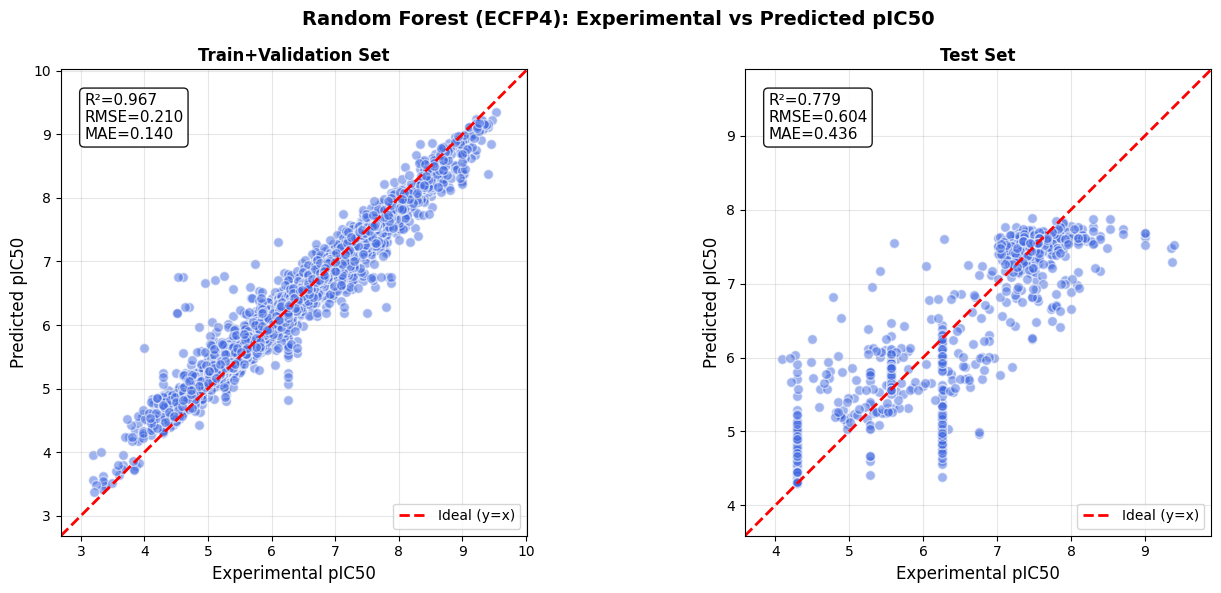

Figure saved: REPORT_rf_experimental_vs_predicted.png


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from final model
y_pred_test = rf_optimized.predict(X_test_fp)
y_pred_trainval = rf_optimized.predict(X_trainval_fp)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest (ECFP4): Experimental vs Predicted pIC50',
             fontsize=14, fontweight='bold')

# Data for each subplot
plot_data = [
    (y_trainval, y_pred_trainval, 'Train+Validation Set', 'RF_FP_optimized_trainval'),
    (y_test,     y_pred_test,     'Test Set',             'RF_FP_optimized_test'),
]

for ax, (y_true, y_pred, title, key) in zip(axes, plot_data):

    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.5, edgecolor='w',
               s=50, color='royalblue')

    # y=x ideal line
    min_val = min(y_true.min(), y_pred.min()) - 0.5
    max_val = max(y_true.max(), y_pred.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', lw=2, label='Ideal (y=x)')

    # Metrics text box
    r2   = results[key]['R2']
    rmse = results[key]['RMSE']
    mae  = results[key]['MAE']
    textstr = f'R²={r2:.3f}\nRMSE={rmse:.3f}\nMAE={mae:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_xlabel('Experimental pIC50', fontsize=12)
    ax.set_ylabel('Predicted pIC50', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('REPORT_rf_experimental_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: REPORT_rf_experimental_vs_predicted.png")

The optimized Random Forest model (ECFP4 features) achieves **R²=0.779, RMSE=0.604, MAE=0.436** on the held-out test set, representing acceptable predictive performance for a BRD4 pIC50 QSAR model. Published QSAR models for BET bromodomain targets typically report test R² in the range of 0.60–0.82, placing our model within the expected range.

**Overfitting gap (Train+Val R²=0.967 vs Test R²=0.779)**  
The large discrepancy between training and test performance is characteristic of Random Forest regressors, which construct predictions by averaging across decision trees trained on bootstrap samples. This ensemble averaging produces near-perfect interpolation on seen data while generalising less reliably to unseen chemical space. The gap does not indicate data leakage; it reflects the known tendency of RF to overfit fingerprint-based representations when the training set contains structurally similar compounds.

**Prediction compression at extreme pIC50 values**  
The test set scatter plot reveals two features typical of RF-based QSAR:  
1. Vertical clustering of predicted values near ~5.0 and ~7.0, despite continuous experimental variation — a consequence of ensemble mean regression pulling predictions toward the central distribution.  
2. Systematic underestimation of highly active compounds (experimental pIC50 > 8), where predicted values plateau around 7.0–7.5. This compression bias arises because very high-activity compounds are underrepresented in the training distribution, providing insufficient tree-splitting signal at the upper tail.

**Implications for candidate selection**  
Given that candidate molecules LIG_1629, LIG_0061, and LIG_1610 were selected primarily on the basis of docking scores (BRD4 vs BRD2 Δscore) rather than QSAR-predicted pIC50, the compression bias at high activity does not compromise the selectivity-driven selection pipeline. The QSAR model serves as a complementary filter to confirm that candidates fall within a chemically reasonable activity range, not as the primary ranking criterion.

#Part 5: Rigorous Validation

##5.1 Validation Overview

In [58]:
import joblib
final_model = joblib.load('final_rf_model.pkl')

In [59]:
# All variables already in memory from Part 4:
#   best_model, X_train, X_val, X_test, y_train, y_val, y_test
#   y_pred_test, X_trainval, y_trainval

from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("PART 5: RIGOROUS VALIDATION")
print("=" * 60)
print("Three complementary validation approaches:")
print("  1. Golbraikh-Tropsha  — checks prediction line vs y=x")
print("  2. Y-Randomization    — confirms genuine SAR learning")
print("  3. Bootstrap CI       — quantifies metric uncertainty")
print()
print(f"Model:   {type(best_model).__name__}")
print(f"Test:    {len(y_test):,} compounds  |  Features: {X_test.shape[1]} ECFP4 bits")

PART 5: RIGOROUS VALIDATION
Three complementary validation approaches:
  1. Golbraikh-Tropsha  — checks prediction line vs y=x
  2. Y-Randomization    — confirms genuine SAR learning
  3. Bootstrap CI       — quantifies metric uncertainty

Model:   RandomForestRegressor
Test:    790 compounds  |  Features: 2048 ECFP4 bits


##5.2 Golbraikh-Tropsha Criteria

In [60]:
def golbraikh_tropsha_criteria(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)

    k       = np.sum(y_true * y_pred) / np.sum(y_pred ** 2)
    k_prime = np.sum(y_true * y_pred) / np.sum(y_true ** 2)

    y_pred_scaled = k * y_pred
    r0_sq = 1 - np.sum((y_true - y_pred_scaled)**2) / np.sum((y_true - np.mean(y_true))**2)

    y_true_scaled = k_prime * y_true
    r0_prime_sq = 1 - np.sum((y_pred - y_true_scaled)**2) / np.sum((y_pred - np.mean(y_pred))**2)

    return {
        'r2':          r2,
        'r0_sq':       r0_sq,
        'r0_prime_sq': r0_prime_sq,
        'k':           k,
        'k_prime':     k_prime,
        'criterion_1': r2 > 0.6,
        'criterion_2': (abs(r2 - r0_sq) < 0.1) or (abs(r2 - r0_prime_sq) < 0.1),
        'criterion_3': (0.85 <= k <= 1.15) or (0.85 <= k_prime <= 1.15),
        'criterion_4': abs(r0_sq - r0_prime_sq) < 0.3
    }

gt = golbraikh_tropsha_criteria(y_test, y_pred_test)

print("GOLBRAIKH-TROPSHA VALIDATION CRITERIA")
print("=" * 50)
print(f"r²:       {gt['r2']:.4f}")
print(f"r0²:      {gt['r0_sq']:.4f}")
print(f"r'0²:     {gt['r0_prime_sq']:.4f}")
print(f"k:        {gt['k']:.4f}")
print(f"k':       {gt['k_prime']:.4f}")
print()
print(f"  1. r² > 0.6:                         {'PASS' if gt['criterion_1'] else 'FAIL'}")
print(f"  2. |r² - r0²| or |r² - r'0²| < 0.1: {'PASS' if gt['criterion_2'] else 'FAIL'}")
print(f"  3. 0.85 ≤ k or k' ≤ 1.15:           {'PASS' if gt['criterion_3'] else 'FAIL'}")
print(f"  4. |r0² - r'0²| < 0.3:              {'PASS' if gt['criterion_4'] else 'FAIL'}")

all_pass = all([gt['criterion_1'], gt['criterion_2'], gt['criterion_3'], gt['criterion_4']])
print(f"\n{'[PASS] All criteria satisfied.' if all_pass else '[WARNING] One or more criteria failed.'}")

GOLBRAIKH-TROPSHA VALIDATION CRITERIA
r²:       0.7787
r0²:      0.7803
r'0²:     0.7215
k:        1.0079
k':       0.9838

  1. r² > 0.6:                         PASS
  2. |r² - r0²| or |r² - r'0²| < 0.1: PASS
  3. 0.85 ≤ k or k' ≤ 1.15:           PASS
  4. |r0² - r'0²| < 0.3:              PASS

[PASS] All criteria satisfied.


##5.3 Y-Randomization Test

###5.3.1 Run Y-Randomization

In [62]:
def y_randomization_test(X, y, model_class, model_params, n_iterations=100, cv=5):
    np.random.seed(42)

    original_model = model_class(**model_params)
    original_r2    = cross_val_score(original_model, X, y, cv=cv, scoring='r2').mean()

    randomized_r2s = []
    for i in range(n_iterations):
        y_shuffled = np.random.permutation(y)
        model      = model_class(**model_params)
        score      = cross_val_score(model, X, y_shuffled, cv=cv, scoring='r2').mean()
        randomized_r2s.append(score)
        if (i + 1) % 25 == 0:
            print(f"  {i+1}/{n_iterations} iterations done...")

    return {
        'original_r2':     original_r2,
        'randomized_r2s':  randomized_r2s,
        'randomized_mean': np.mean(randomized_r2s),
        'randomized_std':  np.std(randomized_r2s),
    }

rf_params = {
    'n_estimators':      best_model.n_estimators,
    'max_depth':         best_model.max_depth,
    'min_samples_split': best_model.min_samples_split,
    'min_samples_leaf':  best_model.min_samples_leaf,
    'max_features':      best_model.max_features,
    'random_state':      42,
    'n_jobs':            -1
}

print("Running Y-randomization test (30 iterations)...\n")
y_rand = y_randomization_test(
    X_trainval, y_trainval,
    RandomForestRegressor, rf_params,
    n_iterations=30
)

Running Y-randomization test (30 iterations)...

  25/30 iterations done...


###5.3.2 Results & Plot

Original R² (5-fold CV): 0.5944
Randomized R² mean:      -0.0822 ± 0.0110
Z-score:                 61.26
p-value:                 0.0000

[PASS] Model significantly outperforms random (z > 3)
  The model has learned genuine structure-activity relationships.


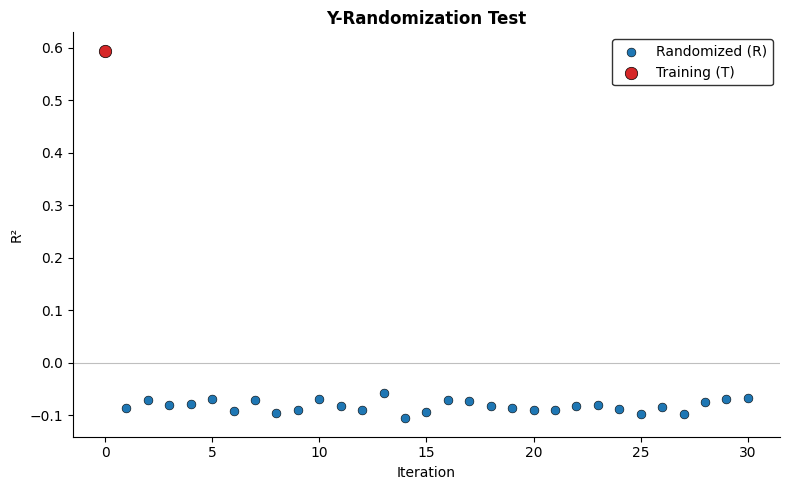

In [63]:
z_score = (y_rand['original_r2'] - y_rand['randomized_mean']) / y_rand['randomized_std']
n_exceed = sum(r >= y_rand['original_r2'] for r in y_rand['randomized_r2s'])
p_value  = n_exceed / len(y_rand['randomized_r2s'])
randomized_max = max(y_rand['randomized_r2s'])

print(f"Original R² (5-fold CV): {y_rand['original_r2']:.4f}")
print(f"Randomized R² mean:      {y_rand['randomized_mean']:.4f} ± {y_rand['randomized_std']:.4f}")
print(f"Z-score:                 {z_score:.2f}")
print(f"p-value:                 {p_value:.4f}")

if z_score > 3 and randomized_max < y_rand['original_r2']:
    print(f"\n[PASS] Model significantly outperforms random (z > 3)")
    print(f"  The model has learned genuine structure-activity relationships.")
else:
    print(f"\n[WARNING] Model may be exploiting chance correlations")
    print(f"  Review your data and model for potential issues.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(1, len(y_rand['randomized_r2s']) + 1), y_rand['randomized_r2s'],
           color='#1f77b4', s=40, edgecolor='black', linewidth=0.4,
           label='Randomized (R)', zorder=3)
ax.scatter(0, y_rand['original_r2'], color='#d62728', s=80,
           edgecolor='black', linewidth=0.5,
           label='Training (T)', zorder=4)
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('R²')
ax.set_title('Y-Randomization Test', fontweight='bold')
ax.legend(frameon=True, edgecolor='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('REPORT_y_randomization.png', dpi=150, bbox_inches='tight')
plt.show()

###5.4 Bootstrap Confidence Intervals

In [64]:
def bootstrap_ci(y_true, y_pred, n_bootstrap=1000, ci=95):
    np.random.seed(42)
    n = len(y_true)
    metrics = {'R2': [], 'RMSE': [], 'MAE': []}

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        metrics['R2'].append(r2_score(yt, yp))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(yt, yp)))
        metrics['MAE'].append(mean_absolute_error(yt, yp))

    alpha = (100 - ci) / 2
    return {m: {'mean':     np.mean(v),
                'ci_lower': np.percentile(v, alpha),
                'ci_upper': np.percentile(v, 100 - alpha)}
            for m, v in metrics.items()}

print("Calculating bootstrap confidence intervals (1000 iterations)...")
boot = bootstrap_ci(y_test, y_pred_test)

print("\nBOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 55)
print(f"{'Metric':<10} {'Mean':>10} {'CI Lower':>12} {'CI Upper':>12}")
print("-" * 55)
for m in ['R2', 'RMSE', 'MAE']:
    d = boot[m]
    print(f"{m:<10} {d['mean']:>10.4f} {d['ci_lower']:>12.4f} {d['ci_upper']:>12.4f}")
print("=" * 55)

Calculating bootstrap confidence intervals (1000 iterations)...

BOOTSTRAP 95% CONFIDENCE INTERVALS
Metric           Mean     CI Lower     CI Upper
-------------------------------------------------------
R2             0.7789       0.7478       0.8082
RMSE           0.6031       0.5655       0.6422
MAE            0.4353       0.4067       0.4644


##5.5 Validation Summary Report

In [67]:
print("=" * 70)
print("QSAR MODEL VALIDATION REPORT")
print("=" * 70)
print(f"Model:    Random Forest (ECFP4 fingerprints)")
print(f"Target:   BRD4 pIC50")
print(f"Date:     {pd.Timestamp.now().strftime('%Y-%m-%d')}")
print()
print("EXTERNAL TEST SET (95% bootstrap CI)")
print("-" * 70)
for m in ['R2', 'RMSE', 'MAE']:
    d = boot[m]
    print(f"  {m:<6} {d['mean']:.4f}  [{d['ci_lower']:.4f} – {d['ci_upper']:.4f}]")
print()
print("Y-RANDOMIZATION")
print("-" * 70)
print(f"  Z-score: {z_score:.2f}   p-value: {p_value:.4f}   {'PASS' if z_score > 3 else 'FAIL'}")
print()
print("GOLBRAIKH-TROPSHA")
print("-" * 70)
for name, result in zip(
    ["r² > 0.6", "|r²−r0²| < 0.1", "0.85 ≤ k ≤ 1.15", "|r0²−r'0²| < 0.3"],
    [gt['criterion_1'], gt['criterion_2'], gt['criterion_3'], gt['criterion_4']]
):
    print(f"  {name:<30} {'PASS' if result else 'FAIL'}")
print("=" * 70)

lines = [
    "QSAR MODEL VALIDATION REPORT",
    f"Model: Random Forest (ECFP4)  |  Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}",
    "",
    f"Test R²:   {boot['R2']['mean']:.4f} [{boot['R2']['ci_lower']:.4f}–{boot['R2']['ci_upper']:.4f}]",
    f"Test RMSE: {boot['RMSE']['mean']:.4f} [{boot['RMSE']['ci_lower']:.4f}–{boot['RMSE']['ci_upper']:.4f}]",
    f"Test MAE:  {boot['MAE']['mean']:.4f} [{boot['MAE']['ci_lower']:.4f}–{boot['MAE']['ci_upper']:.4f}]",
    f"Y-rand Z:  {z_score:.2f}  (p={p_value:.4f})  {'PASS' if z_score > 3 else 'FAIL'}",
    f"GT criteria: {'PASS' if all_pass else 'FAIL'}",
]
with open('REPORT_validation_report.txt', 'w') as f:
    f.write('\n'.join(lines))
print("\nSaved: REPORT_validation_report.txt")

QSAR MODEL VALIDATION REPORT
Model:    Random Forest (ECFP4 fingerprints)
Target:   BRD4 pIC50
Date:     2026-04-03

EXTERNAL TEST SET (95% bootstrap CI)
----------------------------------------------------------------------
  R2     0.7789  [0.7478 – 0.8082]
  RMSE   0.6031  [0.5655 – 0.6422]
  MAE    0.4353  [0.4067 – 0.4644]

Y-RANDOMIZATION
----------------------------------------------------------------------
  Z-score: 61.26   p-value: 0.0000   PASS

GOLBRAIKH-TROPSHA
----------------------------------------------------------------------
  r² > 0.6                       PASS
  |r²−r0²| < 0.1                 PASS
  0.85 ≤ k ≤ 1.15                PASS
  |r0²−r'0²| < 0.3               PASS

Saved: REPORT_validation_report.txt


#Part 6: Model Interpretation & Applicability Domain

##6.1 Setup and Data Loading

In [68]:
import numpy as np
import pandas as pd
import joblib
import io

def upload_and_load_file(var_name, expected_filename=None, file_type='csv'):
    """
    Prompt user to upload a file and return as DataFrame or model.
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    if file_type == 'joblib':
        accept_types = '.joblib,.pkl,.pickle'
    else:
        accept_types = '.csv,.xlsx,.xls,.tsv'

    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept=accept_types, multiple=False)
        print(prompt_msg)
        display(uploader)

        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    if file_type == 'joblib' or filename.endswith(('.joblib', '.pkl', '.pickle')):
        loaded_obj = joblib.load(io.BytesIO(file_content))
        print(f"  ✓ Loaded model '{filename}' (type: {type(loaded_obj).__name__})\n")
        return loaded_obj
    elif filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# --- Check and load each required file ---
required_files = {
    'train_fp':   {'filename': 'DATASET_ecfp4_train.csv',      'type': 'csv'},
    'val_fp':     {'filename': 'DATASET_ecfp4_val.csv',        'type': 'csv'},
    'test_fp':    {'filename': 'DATASET_ecfp4_test.csv',       'type': 'csv'},
    'best_model': {'filename': 'rf_baseline_fingerprints.joblib', 'type': 'joblib'}
}

for var_name, info in required_files.items():
    if var_name not in globals() or globals()[var_name] is None:
        globals()[var_name] = upload_and_load_file(var_name, info['filename'], info['type'])

# Assign to local names for convenience
train_fp   = globals()['train_fp']
val_fp     = globals()['val_fp']
test_fp    = globals()['test_fp']
best_model = globals()['best_model']

# Summary
print("=" * 60)
print("Loaded Files Summary:")
print("=" * 60)
print(f"  train_fp:   {len(train_fp):,} rows × {len(train_fp.columns)} columns")
print(f"  val_fp:     {len(val_fp):,} rows × {len(val_fp.columns)} columns")
print(f"  test_fp:    {len(test_fp):,} rows × {len(test_fp.columns)} columns")
print(f"  best_model: {type(best_model).__name__}")
print("=" * 60)


Loaded Files Summary:
  train_fp:   6,077 rows × 2051 columns
  val_fp:     767 rows × 2051 columns
  test_fp:    790 rows × 2051 columns
  best_model: RandomForestRegressor


In [69]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the best model: Random Forest (Fingerprints) - Baseline
print(f"Loaded model: Random Forest (Fingerprints) - Baseline")
print(f"Number of estimators: {best_model.n_estimators}")


# Prepare feature matrices
metadata_cols = ['molecule_chembl_id', 'smiles', 'pIC50']
feature_cols = [c for c in train_fp.columns if c not in metadata_cols]

X_train = train_fp[feature_cols].values
X_val = val_fp[feature_cols].values
X_test = test_fp[feature_cols].values

y_train = train_fp['pIC50'].values
y_val = val_fp['pIC50'].values
y_test = test_fp['pIC50'].values

# Store SMILES for later use
train_smiles = train_fp['smiles'].values
test_smiles = test_fp['smiles'].values

print(f"\nDatasets loaded:")
print(f"  Train: {len(y_train):,} compounds")
print(f"  Test:  {len(y_test):,} compounds")
print(f"  Features: {len(feature_cols)} ECFP4 bits")


Loaded model: Random Forest (Fingerprints) - Baseline
Number of estimators: 100

Datasets loaded:
  Train: 6,077 compounds
  Test:  790 compounds
  Features: 2048 ECFP4 bits


##6.2 SHAP Analysis for Feature Importance

###6.2.1 Computing SHAP Values

In [70]:
!pip install shap -q
import shap

# Initialize SHAP TreeExplainer for Random Forest
# TreeExplainer is optimized for tree-based models like Random Forest
print("Initializing SHAP TreeExplainer for Random Forest...")
explainer = shap.TreeExplainer(best_model, X_train, feature_perturbation='interventional')
shap_values_test = explainer.shap_values(X_test)

print(f"SHAP values computed. Shape: {shap_values_test.shape}")
# Compute SHAP values for test set
# This may take a while for large datasets
print("Computing SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)

print(f"SHAP values computed.")
print(f"  Shape: {shap_values_test.shape}")
print(f"  (n_samples, n_features) = ({X_test.shape[0]}, {X_test.shape[1]})")


Initializing SHAP TreeExplainer for Random Forest...


 99%|===================| 782/790 [01:20<00:00]       

SHAP values computed. Shape: (790, 2048)
Computing SHAP values for test set...


 99%|===================| 786/790 [01:21<00:00]       

SHAP values computed.
  Shape: (790, 2048)
  (n_samples, n_features) = (790, 2048)


In [71]:
# Also compute SHAP values for training set (for global importance)
print("Computing SHAP values for training set (for global analysis)...")

# Use a subset if training set is very large
if len(X_train) > 1000:
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_train), 1000, replace=False)
    X_train_sample = X_train[sample_idx]
    print(f"  Using random sample of 1000 training compounds")
else:
    X_train_sample = X_train
    print(f"  Using all {len(X_train)} training compounds")

shap_values_train = explainer.shap_values(X_train_sample)
print(f"SHAP values computed for training sample.")


Computing SHAP values for training set (for global analysis)...
  Using random sample of 1000 training compounds


 99%|===================| 989/1000 [01:43<00:01]       

SHAP values computed for training sample.


###6.2.2 Global Feature Importance

In [ ]:
# Calculate mean absolute SHAP value for each feature
mean_shap_importance = np.abs(shap_values_train).mean(axis=0)

# Create DataFrame of feature importance
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_shap_importance
}).sort_values('importance', ascending=False)

print("TOP 20 MOST IMPORTANT FEATURES (by mean |SHAP|)")
print("Model: Random Forest (FP) Baseline")
print("=" * 50)
print(f"{'Rank':<6} {'Feature':<20} {'Mean |SHAP|':>12}")
print("-" * 50)

for i, (_, row) in enumerate(feature_importance_df.head(20).iterrows()):
    print(f"{i+1:<6} {row['feature']:<20} {row['importance']:>12.4f}")

print("=" * 50)


TOP 20 MOST IMPORTANT FEATURES (by mean |SHAP|)
Model: Random Forest (FP) Baseline
Rank   Feature               Mean |SHAP|
--------------------------------------------------
1      ECFP4_875                  0.0302
2      ECFP4_1164                 0.0295
3      ECFP4_917                  0.0285
4      ECFP4_1722                 0.0283
5      ECFP4_666                  0.0275
6      ECFP4_1070                 0.0231
7      ECFP4_1409                 0.0229
8      ECFP4_5                    0.0208
9      ECFP4_464                  0.0205
10     ECFP4_804                  0.0201
11     ECFP4_1145                 0.0183
12     ECFP4_1427                 0.0181
13     ECFP4_206                  0.0177
14     ECFP4_862                  0.0177
15     ECFP4_1738                 0.0171
16     ECFP4_1019                 0.0166
17     ECFP4_1683                 0.0164
18     ECFP4_361                  0.0162
19     ECFP4_904                  0.0154
20     ECFP4_360                  0.0153


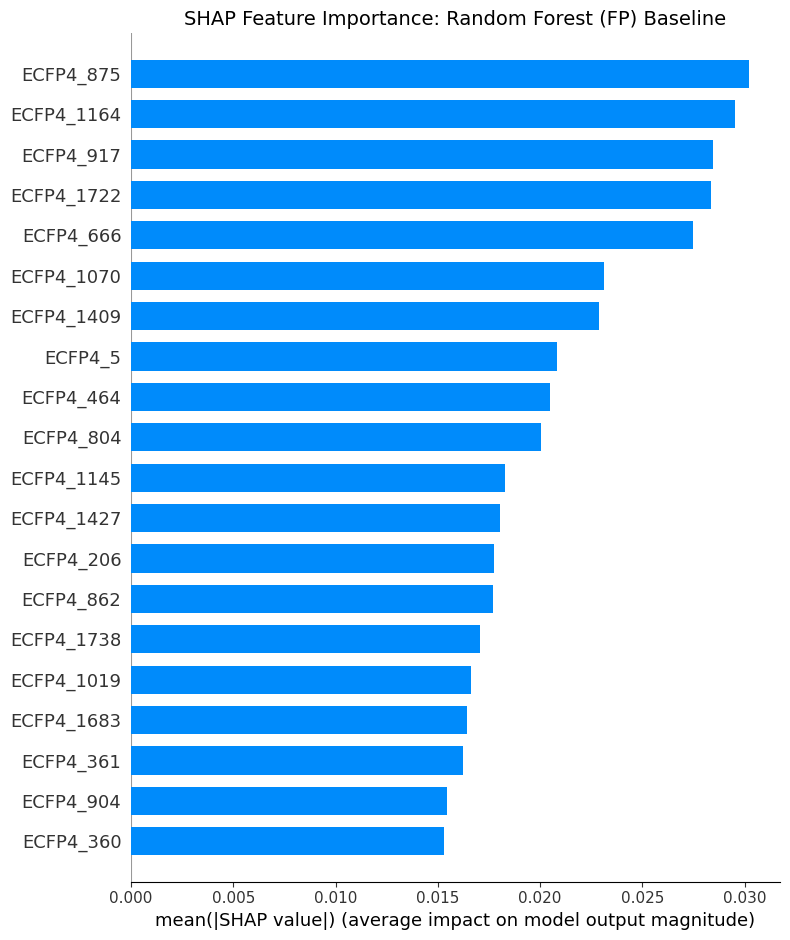

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_train,
    X_train_sample,
    feature_names=feature_cols,
    max_display=20,
    plot_type="bar",   # single aggregated bar plot across all classes
    show=False
)
plt.title('SHAP Feature Importance: Random Forest (FP) Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


###6.2.3 Mapping SHAP to Chemical Substructures

In [ ]:
!pip install rdkit -q
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from collections import defaultdict
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def get_ecfp_bit_info(smiles_list, radius=2, n_bits=2048):
    """
    Extract bit information for ECFP fingerprints.
    Returns a mapping of bit index to (SMILES, atom_idx, radius) tuples.
    """
    bit_info_all = defaultdict(list)

    for smiles in smiles_list[:100]:  # Sample for efficiency
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        bit_info = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius, nBits=n_bits, bitInfo=bit_info
        )

        for bit_idx, atoms_radii in bit_info.items():
            for atom_idx, rad in atoms_radii:
                bit_info_all[bit_idx].append((smiles, atom_idx, rad))

    return bit_info_all

# Get bit information from training compounds
print("Extracting ECFP bit information from training compounds...")
bit_info = get_ecfp_bit_info(train_smiles.tolist())
print(f"Mapped {len(bit_info)} unique bits to molecular substructures.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 19.7 MB/s eta 0:00:00
Extracting ECFP bit information from training compounds...
Mapped 897 unique bits to molecular substructures.


In [ ]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, HTML
import io

def visualize_bit_substructure(bit_idx, bit_info_dict):
    if bit_idx not in bit_info_dict:
        return None, None, None, None, None

    for smi, atom_idx, radius in bit_info_dict[bit_idx]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        atom_map = {}
        submol = Chem.PathToSubmol(mol, env, atomMap=atom_map)

        if submol.GetNumAtoms() > 0:
            highlight_atoms = list(atom_map.keys())
            highlight_bonds = list(env)
            return mol, submol, highlight_atoms, highlight_bonds, smi

    return None, None, None, None, None

print("\nTop Most Important ECFP Bits and Their Substructures:")
print("=" * 60)

top_bits = feature_importance_df.head(10)['feature'].tolist()
visualized_count = 0
svg_cells = []

for bit_name in top_bits:
    if visualized_count >= 6:  # 2 rows x 3 cols
        break

    try:
        bit_idx = int(bit_name.split('_')[-1])
    except:
        continue

    result = visualize_bit_substructure(bit_idx, bit_info)
    if result[0] is not None:
        mol, submol, highlight_atoms, highlight_bonds, smi = result
        importance = feature_importance_df[
            feature_importance_df['feature'] == bit_name
        ]['importance'].values[0]

        Chem.rdDepictor.Compute2DCoords(mol)

        drawer = rdMolDraw2D.MolDraw2DSVG(350, 300)
        drawer.drawOptions().addAtomIndices = False

        atom_colors = {a: (1.0, 0.7, 0.3) for a in highlight_atoms}
        bond_colors = {b: (1.0, 0.7, 0.3) for b in highlight_bonds}
        atom_radii = {a: 0.4 for a in highlight_atoms}

        drawer.DrawMolecule(
            mol,
            highlightAtoms=highlight_atoms,
            highlightBonds=highlight_bonds,
            highlightAtomColors=atom_colors,
            highlightBondColors=bond_colors,
            highlightAtomRadii=atom_radii,
        )
        drawer.FinishDrawing()
        svg = drawer.GetDrawingText().replace("svg:", "")

        sub_smi = Chem.MolToSmiles(submol)
        caption = f"<b>Bit {bit_idx}</b> (imp: {importance:.4f})<br>{sub_smi}"
        svg_cells.append(f'<td style="text-align:center; padding:10px;">{svg}<br>{caption}</td>')
        visualized_count += 1

# Build HTML table with 3 columns
ncols = 3
html = '<table style="border-collapse: collapse;">'
for i in range(0, len(svg_cells), ncols):
    html += '<tr>' + ''.join(svg_cells[i:i+ncols]) + '</tr>'
html += '</table>'

display(HTML(html))



Top Most Important ECFP Bits and Their Substructures:


###6.2.4 Local Explanations for Individual Predictions

In [ ]:
def explain_prediction(idx, X, y_true, y_pred, shap_values, feature_names, smiles=None):
    """
    Generate detailed explanation for a single prediction.
    """
    print(f"\nPREDICTION EXPLANATION (Test compound #{idx})")
    print("=" * 60)

    if smiles is not None:
        print(f"SMILES: {smiles[:60]}..." if len(smiles) > 60 else f"SMILES: {smiles}")

    print(f"True pIC50:      {y_true[idx]:.2f}")
    print(f"Predicted pIC50: {y_pred[idx]:.2f}")
    print(f"Error:           {y_pred[idx] - y_true[idx]:.2f}")
    print()

    # Get SHAP values for this compound
    shap_vals = shap_values[idx]

    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1]

    print("Top 10 features influencing this prediction:")
    print(f"{'Feature':<20} {'Value':>8} {'SHAP':>10} {'Direction':>12}")
    print("-" * 55)

    for i in sorted_idx[:10]:
        feat_name = feature_names[i]
        feat_val = X[idx, i]
        shap_val = shap_vals[i]
        direction = '↑ potency' if shap_val > 0 else '↓ potency'
        print(f"{feat_name:<20} {feat_val:>8.0f} {shap_val:>10.4f} {direction:>12}")

    print("=" * 60)

# Get predictions
y_pred_test = best_model.predict(X_test)

# Explain predictions for compounds with best, worst, and median predictions
sorted_by_pred = np.argsort(y_pred_test)

# Most potent prediction
explain_prediction(
    sorted_by_pred[-1], X_test, y_test, y_pred_test,
    shap_values_test, feature_cols, test_smiles[sorted_by_pred[-1]]
)

# Least potent prediction
explain_prediction(
    sorted_by_pred[0], X_test, y_test, y_pred_test,
    shap_values_test, feature_cols, test_smiles[sorted_by_pred[0]]
)



PREDICTION EXPLANATION (Test compound #80)
SMILES: CCOC(=O)CC(=O)NCCCCNc1nc2cc(OCCOC)ccc2n2c(C)nnc12
True pIC50:      7.47
Predicted pIC50: 7.88
Error:           0.41

Top 10 features influencing this prediction:
Feature                 Value       SHAP    Direction
-------------------------------------------------------
ECFP4_1658                  1     0.1266    ↑ potency
ECFP4_917                   1     0.1233    ↑ potency
ECFP4_1696                  1     0.1005    ↑ potency
ECFP4_1164                  1     0.0964    ↑ potency
ECFP4_592                   1     0.0896    ↑ potency
ECFP4_1056                  1     0.0773    ↑ potency
ECFP4_1434                  1     0.0766    ↑ potency
ECFP4_1439                  1     0.0727    ↑ potency
ECFP4_45                    1     0.0718    ↑ potency
ECFP4_1416                  1     0.0643    ↑ potency

PREDICTION EXPLANATION (Test compound #277)
SMILES: COC(=O)N1c2ccc3c(nc(Cc4ccccc4)n3[C@H]3CC[C@@](C)(C(=O)O)CC3)...
True pIC50:      4.

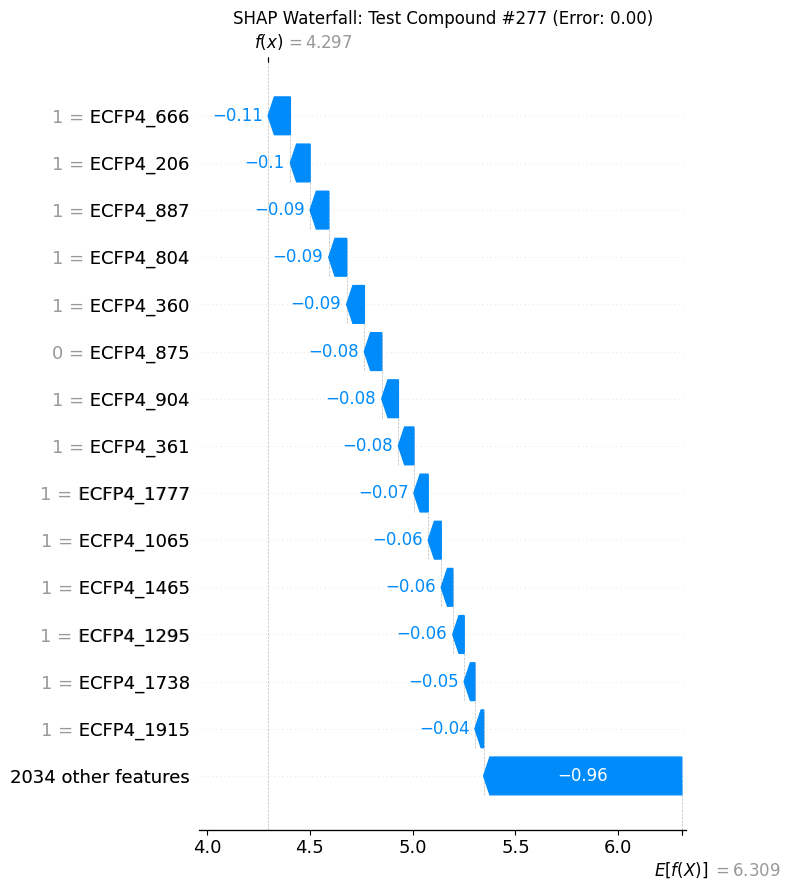

In [ ]:
# SHAP waterfall plot for individual prediction
plt.figure(figsize=(12, 6))

# Select a compound with good prediction accuracy
errors = np.abs(y_pred_test - y_test)
good_pred_idx = np.argmin(errors)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_test[good_pred_idx],
        base_values=explainer.expected_value,
        data=X_test[good_pred_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=False
)

plt.title(f'SHAP Waterfall: Test Compound #{good_pred_idx} (Error: {errors[good_pred_idx]:.2f})', fontsize=12)
plt.tight_layout()
plt.show()


##6.3 Saving Interpretation Results

In [ ]:
import os
import shutil
from google.colab import files

# Create interpretation directory
os.makedirs('interpretation', exist_ok=True)

# Save feature importance
feature_importance_df.to_csv('interpretation/DATASET_shap_feature_importance.csv', index=False)

# Save test predictions
pred_df = pd.DataFrame({
    'smiles': test_smiles,
    'y_true': y_test,
    'y_pred': y_pred_test,
})
pred_df.to_csv('interpretation/DATASET_test_predictions.csv', index=False)

# Save SHAP values
np.save('interpretation/DATASET_shap_values_test.npy', shap_values_test)

# Auto-download all files
download_files = [
    'shap_summary_plot.png',
]

for f in download_files:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"Not found: {f}")

shutil.make_archive('interpretation', 'zip', '.', 'interpretation')
files.download('interpretation.zip')

print("Downloaded: interpretation.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shap_summary_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: interpretation.zip


#Part 7: Model Deployment

BRD2 pIC50 predictions for the BRD4 top-2000 candidate library were
generated on HPC using the trained RF model (rf_optimized_fingerprints.joblib)
with ECFP4 fingerprints. Prediction results are available in
`BRD4_1M_Top2000.csv`. Full deployment pipeline is available in
the BRD4 QSAR notebook.